# Toy diffusion + score fields in 2D (static + rotating trajectories)

**Goal.** Build a *toy* score-based/diffusion model where we can:
- Observe how a distribution at a final diffusion time **T**, $p_T(x)$, maps back to an earlier time $p_\tau(x)$ via **reverse-time generation**.
- Study and visualize the **score field**

$$
s(x,t)=\nabla_x \log p_t(x),
$$

its **conditional** and **guided** variants, and how these fields behave under a *rotating internal-time dynamics*.

This notebook is intentionally **exactly solvable** in key places, so we can compare:
- **Exact** scores (analytic), vs
- **Empirical** scores (finite dataset KDE).

---

## Roadmap (required structure)

1. **Intro + notation** (diffusion time $t$ vs internal time $u$)
2. **Forward diffusion:** SDE → Fokker–Planck → OU/VP closed form
3. **Score:** exact score, Tweedie/Bayes denoiser identity, empirical KDE score
4. **Reverse process:** reverse SDE + probability-flow ODE
5. **Conditional/unconditional/guidance:** exact definitions + sampling + visualization
6. **Divergence/curl:** maps of $\nabla\cdot s$ and $\nabla\times s$, interpretation
7. **Two-time extension:** internal time $u$ (rotation) vs diffusion time $t$; operator $P$ mapping score fields across $u$
8. **Spectral view:** Fourier in angle; damping of high-frequency modes with diffusion time; (plus a concrete Laplace-transform OU solve)
9. **Research extensions:** FDT, Landau-style order parameter, minimal replica computation (REM)
10. **Summary + next experiments**

---

## Notation (keep this straight)

### Diffusion time $t$
- Continuous variable controlling **noise level**.
- $t=0$ is **data**, $t=T$ is **noise** (approximately).

### Internal time $u$
- Discrete index for **physical evolution** of a trajectory/object:

$$
x(u)\in \mathbb{R}^2,\quad u=0,1,\dots,T_{\text{int}}-1.
$$

- We will build a dataset of rotating trajectories in $\mathbb{R}^2$.

### Forward diffusion (VP/OU-style)

We use a simple **Ornstein–Uhlenbeck** (variance-preserving) forward diffusion:

$$
dX_t = f(X_t,t)\,dt + g(t)\,dW_t,\qquad 
f(x,t)= -\frac{\beta}{2}x,\quad 
g(t)=\sqrt{\beta},
$$

with constant $\beta>0$. This has a closed form.

### Scores we will study

Unconditional:

$$
s_{\text{uncond}}(x,t)=\nabla_x\log p_t(x).
$$

Conditional (label $y$):

$$
s_{\text{cond}}(x,t\mid y)=\nabla_x\log p_t(x\mid y).
$$

Classifier guidance:

$$
s_{\text{guided}}(x,t)=s_{\text{uncond}}(x,t)+w\,\nabla_x\log p(y\mid x,t).
$$

Classifier-free guidance:

$$
s_{\text{cfg}}(x,t)=(1+w)\,s_{\text{cond}}(x,t\mid y)-w\,s_{\text{uncond}}(x,t).
$$

We will implement all of these and visualize their vector fields.

---

## Toy systems

### Toy A (static)

A 2D Gaussian mixture with **analytic** $p_t$ under OU corruption, so **exact score is available**.

### Toy B (dynamic trajectories)

A dataset of trajectories where internal dynamics is an **exact rotation**:

$$
x(u)=R(\omega u)\,x(0),\quad 
R(\theta)=
\begin{pmatrix}
\cos\theta & -\sin\theta\\
\sin\theta & \cos\theta
\end{pmatrix}.
$$

Then we apply OU corruption *independently per frame* to create $p_t(x\mid u)$.
We will study how the score field propagates across internal time $u$.

---

**Implementation constraints satisfied:** numpy, scipy, matplotlib only; CPU-only; fast.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import logsumexp
from scipy.interpolate import RegularGridInterpolator

np.random.seed(0)

# Matplotlib defaults: keep it simple and readable
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True


## Helper utilities (geometry, grids, plotting)

We'll use:
- rotation matrices
- 2D grids for evaluating densities and scores
- quiver/stream plotting helpers
- divergence/curl numerical operators


In [5]:
def rotmat(theta: float) -> np.ndarray:
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

def make_grid(xmin=-4.0, xmax=4.0, n=81):
    xs = np.linspace(xmin, xmax, n)
    ys = np.linspace(xmin, xmax, n)
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    pts = np.stack([X.ravel(), Y.ravel()], axis=1)
    return xs, ys, X, Y, pts

def quiver_field(ax, X, Y, U, V, stride=4, scale=None, title=None):
    ax.quiver(X[::stride, ::stride], Y[::stride, ::stride],
              U[::stride, ::stride], V[::stride, ::stride], scale=scale)
    ax.set_aspect("equal")
    if title:
        ax.set_title(title)

def stream_field(ax, xs, ys, U, V, density=1.2, title=None):
    ax.streamplot(xs, ys, U, V, density=density)
    ax.set_aspect("equal")
    if title:
        ax.set_title(title)

def divergence_and_curl(xs, ys, U, V):
    """
    U,V are shape (ny,nx) corresponding to grid (xs,ys).
    Returns div, curl (both shape (ny,nx)).
    curl is scalar curl in 2D: dV/dx - dU/dy
    """
    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]

    dU_dy, dU_dx = np.gradient(U, dy, dx, edge_order=2)
    dV_dy, dV_dx = np.gradient(V, dy, dx, edge_order=2)

    div = dU_dx + dV_dy
    curl = dV_dx - dU_dy
    return div, curl

def plot_scalar(ax, X, Y, Z, title=None, cmap="viridis"):
    im = ax.pcolormesh(X, Y, Z, shading="auto", cmap=cmap)
    ax.set_aspect("equal")
    if title:
        ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


# 1) Forward diffusion: SDE → Fokker–Planck → OU closed form

We use the **variance-preserving OU / VP** forward SDE in $\mathbb{R}^2$:

$$
dX_t = -\frac{\beta}{2}X_t\,dt + \sqrt{\beta}\,dW_t,\qquad \beta>0.
$$

## Closed-form solution (derivation sketch)

Multiply both sides by the integrating factor $e^{\beta t/2}$:

$$
d\!\left(e^{\beta t/2}X_t\right) = e^{\beta t/2}\sqrt{\beta}\,dW_t.
$$

Integrating from $0$ to $t$,

$$
X_t = e^{-\beta t/2}X_0 + \sqrt{\beta}\int_0^t e^{-\beta (t-s)/2}\,dW_s.
$$

The stochastic integral is Gaussian with mean $0$ and covariance

$$
\beta \int_0^t e^{-\beta (t-s)}\,ds \; I
= (1-e^{-\beta t})\,I.
$$

Define:

$$
\alpha(t)=e^{-\beta t/2},\qquad 
\sigma^2(t)=1-e^{-\beta t}.
$$

Then the *marginal corruption model* is:

$$
X_t = \alpha(t)X_0 + \sigma(t)Z,\qquad Z\sim \mathcal{N}(0,I).
$$

This is the standard VP diffusion with constant $\beta$.

---

## Fokker–Planck equation (and why it matches the SDE)

For the SDE

$$
dX_t=f(X_t,t)\,dt+g(t)\,dW_t
$$

the density $p_t(x)$ satisfies the Fokker–Planck PDE:

$$
\partial_t p_t(x)
=
-\nabla\cdot\!\big(f(x,t)p_t(x)\big)
+\frac12 \nabla\cdot\!\left(g(t)^2\nabla p_t(x)\right).
$$

Here $f(x,t)=-(\beta/2)x$, $g(t)^2=\beta$, giving

$$
\partial_t p_t(x)
=
\nabla\cdot\!\left(\frac{\beta}{2}x\,p_t(x)\right)
+
\frac{\beta}{2}\Delta p_t(x).
$$

We'll verify the OU marginal formula numerically by simulation.


In [6]:
def alpha_sigma(t, beta):
    alpha = np.exp(-0.5 * beta * t)
    sigma2 = 1.0 - np.exp(-beta * t)
    sigma = np.sqrt(sigma2)
    return alpha, sigma

def simulate_forward_ou(x0, ts, beta):
    """
    Euler-Maruyama simulation for forward OU SDE:
        dX = -(beta/2) X dt + sqrt(beta) dW
    using small dt steps between times in ts.
    
    Returns list of arrays [X(t0), X(t1), ...] with X(t0)=x0.
    """
    ts = np.array(ts, dtype=float)
    assert np.all(np.diff(ts) >= 0)
    x = x0.copy()
    out = [x.copy()]

    # choose fine dt
    dt_fine = 1e-3
    t_curr = ts[0]
    idx = 1
    while idx < len(ts):
        t_next = ts[idx]
        while t_curr + dt_fine < t_next - 1e-12:
            dt = dt_fine
            x = x + (-0.5 * beta * x) * dt + np.sqrt(beta * dt) * np.random.randn(*x.shape)
            t_curr += dt
        dt = t_next - t_curr
        if dt > 0:
            x = x + (-0.5 * beta * x) * dt + np.sqrt(beta * dt) * np.random.randn(*x.shape)
            t_curr = t_next
        out.append(x.copy())
        idx += 1
    return out


# 2) Toy system A: a 2D Gaussian mixture with exact $p_t$ and exact score

We define a **4-component** isotropic Gaussian mixture in $\mathbb{R}^2$:

$$
p_0(x)=\sum_{k=1}^K \pi_k\,\mathcal{N}(x;\mu_k,\sigma_0^2 I).
$$

Under the OU corruption model

$$
X_t=\alpha(t)X_0+\sigma(t)Z,
$$

the distribution remains a Gaussian mixture with:
- same weights $\pi_k$,
- means $\mu_k(t)=\alpha(t)\mu_k$,
- covariances $\Sigma_k(t)=\alpha(t)^2\sigma_0^2I+\sigma(t)^2I = s_t^2 I$ (same for all $k$ if $\sigma_0$ is shared).

So:

$$
p_t(x)=\sum_k \pi_k \,\mathcal{N}(x;\alpha\mu_k, s_t^2 I),
\qquad
s_t^2=\alpha^2\sigma_0^2+\sigma^2.
$$

---

## Exact score for an isotropic GMM

Let

$$
\phi_k(x)=\pi_k \mathcal{N}(x; m_k, s^2 I).
$$

Then

$$
p(x)=\sum_k \phi_k(x),
\qquad
r_k(x)=\frac{\phi_k(x)}{\sum_j \phi_j(x)}.
$$

The score is:

$$
\nabla_x\log p(x)
=
\sum_k r_k(x)\,\nabla_x\log \mathcal{N}(x;m_k,s^2I)
=
\sum_k r_k(x)\,\frac{m_k-x}{s^2}.
$$

We'll use this to compute:
- exact unconditional score $s_{\text{uncond}}(x,t)$,
- exact conditional score $s_{\text{cond}}(x,t\mid y)$ for labels $y$.

We'll assign labels by grouping components: two components per class.


In [7]:
class IsotropicGMM2D:
    def __init__(self, weights, means, sigma0, labels=None):
        """
        weights: (K,)
        means:   (K,2)
        sigma0:  scalar, base isotropic std at t=0
        labels:  (K,) integer label per component (optional)
        """
        self.weights = np.array(weights, dtype=float)
        self.weights = self.weights / self.weights.sum()
        self.means0 = np.array(means, dtype=float)
        self.K = self.means0.shape[0]
        self.sigma0 = float(sigma0)
        if labels is None:
            self.labels = None
        else:
            self.labels = np.array(labels, dtype=int)
    
    def params_at_t(self, t, beta):
        a, sig = alpha_sigma(t, beta)
        means_t = a * self.means0
        s2 = (a**2) * (self.sigma0**2) + (sig**2)
        return means_t, s2
    
    def sample_x0(self, n):
        k = np.random.choice(self.K, size=n, p=self.weights)
        x = self.means0[k] + self.sigma0 * np.random.randn(n, 2)
        return x, k
    
    def sample_xt(self, n, t, beta):
        x0, k = self.sample_x0(n)
        a, sig = alpha_sigma(t, beta)
        xt = a * x0 + sig * np.random.randn(n, 2)
        return xt, x0, k
    
    def logp_and_score(self, x, t, beta, label=None):
        """
        x: (N,2)
        If label is None: unconditional p_t(x)
        If label is int:  conditional p_t(x | y=label)
        Returns logp (N,), score (N,2)
        """
        x = np.atleast_2d(x)
        means_t, s2 = self.params_at_t(t, beta)
        
        if label is None:
            w = self.weights
            means = means_t
        else:
            assert self.labels is not None, "No labels provided for conditional queries."
            mask = (self.labels == label)
            w = self.weights[mask]
            w = w / w.sum()
            means = means_t[mask]

        # log phi_k(x) up to normalization
        # log N = -log(2π s^2) - ||x-m||^2/(2s^2)
        # include log weights
        x2 = np.sum(x**2, axis=1, keepdims=True)             # (N,1)
        m2 = np.sum(means**2, axis=1, keepdims=True).T       # (1,K')
        xm = x @ means.T                                     # (N,K')
        d2 = x2 + m2 - 2*xm                                  # (N,K')
        
        log_norm = -np.log(2*np.pi*s2)                       # in 2D: -log(2π s^2)
        log_phi = np.log(w[None, :]) + log_norm - 0.5 * d2 / s2
        
        logp = logsumexp(log_phi, axis=1)
        resp = np.exp(log_phi - logp[:, None])               # responsibilities r_k(x)
        
        # score: sum_k r_k (m_k - x)/s2
        mean_post = resp @ means                             # (N,2)
        score = (mean_post - x) / s2
        return logp, score

# Define Toy A: 4 Gaussians on a ring
r0 = 2.0
angles = np.array([0.0, 0.5*np.pi, np.pi, 1.5*np.pi])
means = np.stack([r0*np.cos(angles), r0*np.sin(angles)], axis=1)
weights = np.ones(4) / 4
sigma0 = 0.25

# Labels: group opposite points into 2 classes
# y=0: (0, pi), y=1: (pi/2, 3pi/2)
labels = np.array([0, 1, 0, 1])

gmm = IsotropicGMM2D(weights=weights, means=means, sigma0=sigma0, labels=labels)

beta = 1.0
T = 5.0

print("Toy A means:\n", means)
print("labels:", labels)


Toy A means:
 [[ 2.0000000e+00  0.0000000e+00]
 [ 1.2246468e-16  2.0000000e+00]
 [-2.0000000e+00  2.4492936e-16]
 [-3.6739404e-16 -2.0000000e+00]]
labels: [0 1 0 1]


## Verify forward OU marginal formula vs simulation

We compare:
1) Analytic: $X_t=\alpha X_0+\sigma Z$.
2) Euler–Maruyama simulation of the OU SDE.

We will:
- sample $X_0$ from the GMM
- simulate forward OU SDE to times $t\in\{0,0.5,1.5,3,5\}$
- compare scatter plots and (mean, covariance) statistics

t    | mean(sim)         | mean(analytic)
0.0 | [0.00929745 0.01783598] | [0.00929745 0.01783598]
0.5 | [0.00225683 0.02251289] | [0.00938075 0.01180912]
1.5 | [-0.00454219  0.02680499] | [0.01846227 0.0269521 ]
3.0 | [-0.00251292  0.00797527] | [-0.01364508 -0.00475751]
5.0 | [ 0.00655222 -0.0085588 ] | [ 0.01451821 -0.0044546 ]


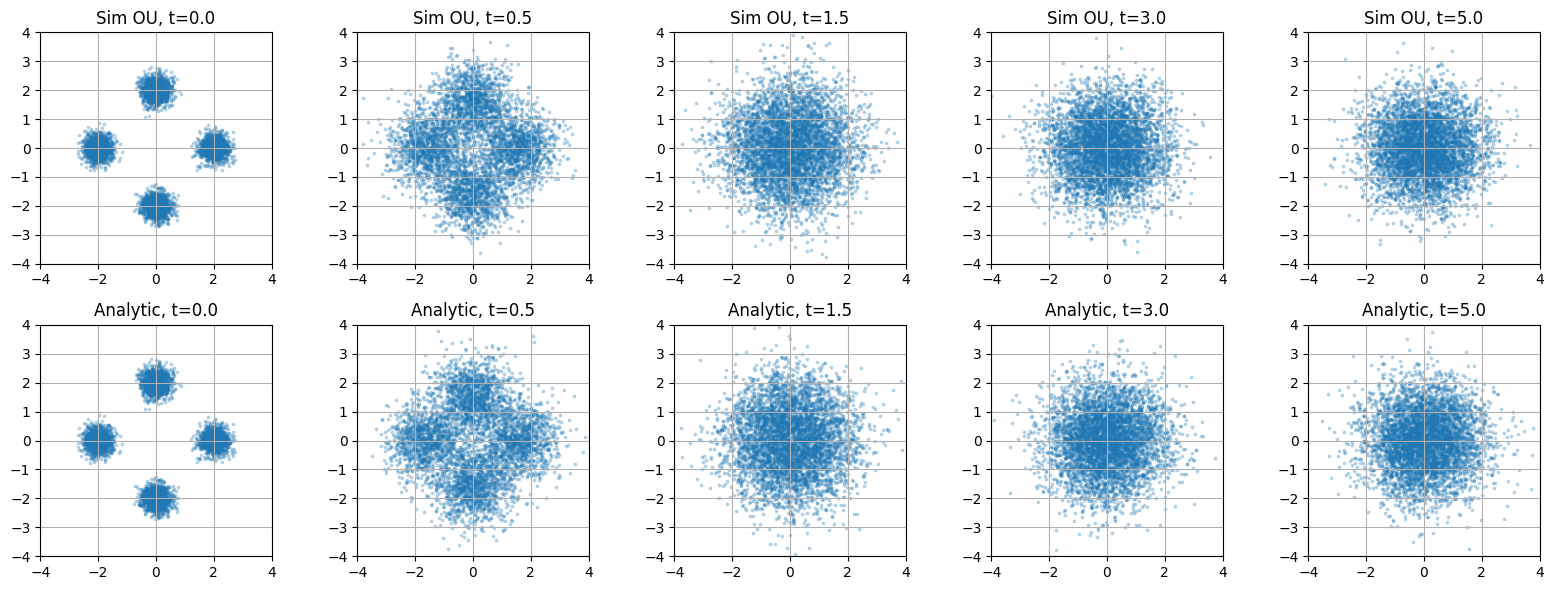

In [8]:
ts = [0.0, 0.5, 1.5, 3.0, 5.0]
n = 5000
x0, _ = gmm.sample_x0(n)

# Simulate forward OU SDE
traj = simulate_forward_ou(x0, ts, beta)
traj = [arr.copy() for arr in traj]

# Analytic sampling using marginal corruption formula
analytic = []
for t in ts:
    a, sig = alpha_sigma(t, beta)
    xt = a * x0 + sig * np.random.randn(n, 2)
    analytic.append(xt)

def mean_cov(x):
    m = x.mean(axis=0)
    C = np.cov(x.T)
    return m, C

print("t    | mean(sim)         | mean(analytic)")
for t, xs, xa in zip(ts, traj, analytic):
    ms, Cs = mean_cov(xs)
    ma, Ca = mean_cov(xa)
    print(f"{t:3.1f} | {ms} | {ma}")

fig, axes = plt.subplots(2, len(ts), figsize=(3.2*len(ts), 6))
for j, t in enumerate(ts):
    axes[0, j].scatter(traj[j][:,0], traj[j][:,1], s=3, alpha=0.25)
    axes[0, j].set_title(f"Sim OU, t={t}")
    axes[0, j].set_aspect("equal")
    axes[0, j].set_xlim(-4,4); axes[0, j].set_ylim(-4,4)

    axes[1, j].scatter(analytic[j][:,0], analytic[j][:,1], s=3, alpha=0.25)
    axes[1, j].set_title(f"Analytic, t={t}")
    axes[1, j].set_aspect("equal")
    axes[1, j].set_xlim(-4,4); axes[1, j].set_ylim(-4,4)

plt.tight_layout()
plt.show()


# 3) Score and Tweedie / Bayes denoiser identity

For our OU corruption model (constant-$\beta$ VP diffusion), we have:

$$
X_t = \alpha X_0 + \sigma Z,\quad Z\sim \mathcal{N}(0,I).
$$

## Tweedie identity (posterior mean denoiser)

A standard identity for Gaussian corruption says:

$$
\mathbb{E}[X_0\mid X_t=x] = \frac{1}{\alpha}\Big(x + \sigma^2 \nabla_x \log p_t(x)\Big).
$$

Equivalently:

$$
\nabla_x \log p_t(x) = \frac{\alpha\,\mathbb{E}[X_0\mid X_t=x]-x}{\sigma^2}.
$$

**Interpretation.** The score points toward the Bayes-optimal denoised mean:
- When $\sigma^2$ is large (high noise), score magnitude shrinks.
- When $\sigma^2$ is small (low noise), score becomes sharper.

We will verify this identity in two ways:
1) Using the exact GMM score $s(x,t)$.
2) Estimating $\mathbb{E}[X_0\mid X_t=x]$ via the exact posterior responsibilities.

---

## Exact posterior mean for isotropic GMM under corruption

Given a component index $k$, the clean prior is:

$$
X_0\mid k \sim \mathcal{N}(\mu_k, \sigma_0^2 I),
$$

and corruption gives:

$$
X_t \mid k \sim \mathcal{N}(\alpha\mu_k, s_t^2 I), \quad s_t^2=\alpha^2\sigma_0^2+\sigma^2.
$$

Also, $X_0\mid X_t=x,k$ is Gaussian with mean

$$
\mathbb{E}[X_0\mid X_t=x, k]
= \mu_k + \frac{\alpha\sigma_0^2}{s_t^2}\,(x-\alpha\mu_k).
$$

Then average over components using posterior responsibilities $r_k(x,t)$.

We'll implement the posterior mean denoiser and check Tweedie's identity numerically.

Mean ||E[X0|Xt]-Tweedie|| at t=1.5: 2.222e-16


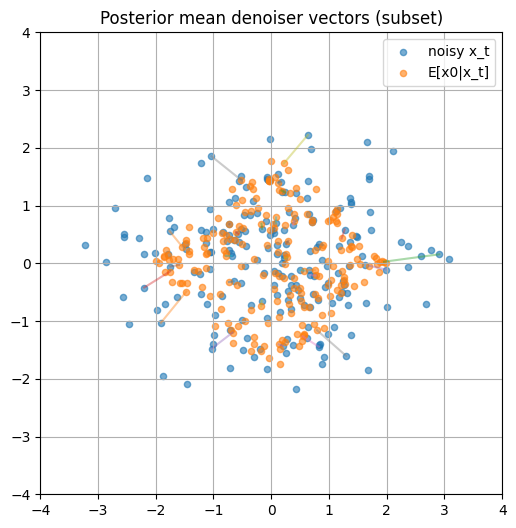

In [9]:
def posterior_mean_x0_given_xt_gmm(x, t, beta, gmm: IsotropicGMM2D):
    """
    Exact posterior mean E[X0 | Xt=x] for isotropic GMM with shared sigma0.
    x: (N,2)
    returns (N,2)
    """
    x = np.atleast_2d(x)
    means_t, s2 = gmm.params_at_t(t, beta)
    a, sig = alpha_sigma(t, beta)
    # responsibilities under p_t
    logp, score = gmm.logp_and_score(x, t, beta, label=None)

    # compute responsibilities explicitly again (we also can reuse score, but let's do clean)
    x2 = np.sum(x**2, axis=1, keepdims=True)
    m2 = np.sum(means_t**2, axis=1, keepdims=True).T
    xm = x @ means_t.T
    d2 = x2 + m2 - 2*xm

    log_norm = -np.log(2*np.pi*s2)
    log_phi = np.log(gmm.weights[None, :]) + log_norm - 0.5 * d2 / s2
    logp_check = logsumexp(log_phi, axis=1)
    resp = np.exp(log_phi - logp_check[:, None])

    # posterior mean in each component:
    # E[X0|x,k] = mu_k + (a*sigma0^2/s2)*(x - a*mu_k)
    coef = (a * gmm.sigma0**2) / s2
    mu = gmm.means0  # (K,2)
    # x - a*mu_k
    diff = x[:, None, :] - a * mu[None, :, :]   # (N,K,2)
    mu_post_k = mu[None, :, :] + coef * diff    # (N,K,2)
    mean_post = np.sum(resp[:, :, None] * mu_post_k, axis=1)
    return mean_post

# Verify Tweedie identity on random xt points
t_test = 1.5
xt, x0_true, _ = gmm.sample_xt(n=8000, t=t_test, beta=beta)

# pick a subset of points to test
idx = np.random.choice(len(xt), size=200, replace=False)
x_query = xt[idx]

logp, score = gmm.logp_and_score(x_query, t_test, beta)

a, sig = alpha_sigma(t_test, beta)
sigma2 = sig**2

denoiser = posterior_mean_x0_given_xt_gmm(x_query, t_test, beta, gmm)
tweedie_rhs = (x_query + sigma2 * score) / a

err = np.linalg.norm(denoiser - tweedie_rhs, axis=1).mean()
print(f"Mean ||E[X0|Xt]-Tweedie|| at t={t_test}: {err:.3e}")

# Visual sanity: show denoised vectors from some noisy points
fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.scatter(x_query[:,0], x_query[:,1], s=20, alpha=0.6, label="noisy x_t")
ax.scatter(denoiser[:,0], denoiser[:,1], s=20, alpha=0.6, label="E[x0|x_t]")
for i in range(30):
    ax.plot([x_query[i,0], denoiser[i,0]], [x_query[i,1], denoiser[i,1]], alpha=0.4)
ax.set_title("Posterior mean denoiser vectors (subset)")
ax.set_aspect("equal")
ax.set_xlim(-4,4); ax.set_ylim(-4,4)
ax.legend()
plt.show()


# 4) Empirical score estimation (KDE) vs exact score

Given samples $\{x_i\}_{i=1}^n \sim p_t$, a Gaussian KDE is:

$$
\hat p_t(x)=\frac1n\sum_{i=1}^n \mathcal{N}(x;x_i,h^2I).
$$

Its score is:

$$
\nabla_x\log \hat p_t(x)
=
\frac{\sum_i \mathcal{N}(x;x_i,h^2I)\,\frac{x_i-x}{h^2}}{\sum_j \mathcal{N}(x;x_j,h^2I)}
=
\frac{\hat{\mathbb{E}}[X\mid x]-x}{h^2},
$$

where $\hat{\mathbb{E}}[X\mid x]$ is the kernel-weighted local mean (**mean shift**).

We will:
- sample a finite dataset from the exact $p_t$,
- compute KDE score on a grid,
- compare against exact score with:
  - MSE on the grid
  - cosine similarity / angle error
  - show effect of dataset size $n$

**Important:** The true score is always a gradient field, so its curl is **exactly zero** in continuous math:

$$
\nabla\times \nabla \log p_t(x)=0.
$$

Empirical KDE scores can exhibit small nonzero curl because of finite samples, bandwidth choice, and numerical discretization.


n=  200 | MSE= 41.1964 | mean cos= 0.888 | mean angle(deg)= 21.60
n=  500 | MSE= 21.7698 | mean cos= 0.894 | mean angle(deg)= 20.60
n= 2000 | MSE= 10.3891 | mean cos= 0.950 | mean angle(deg)= 13.72
n= 8000 | MSE=  6.3303 | mean cos= 0.971 | mean angle(deg)=  9.04


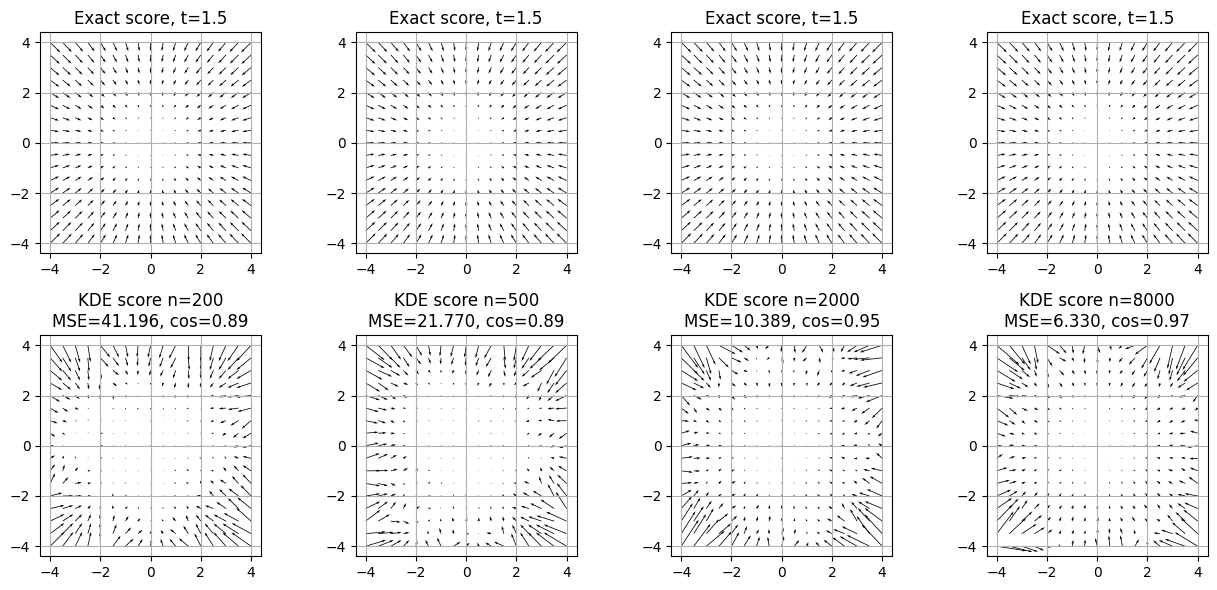

In [10]:
def kde_logp_and_score(grid_pts, samples, h):
    """
    Gaussian KDE with isotropic bandwidth h.
    grid_pts: (G,2)
    samples:  (n,2)
    Returns logp (G,), score (G,2)
    """
    grid_pts = np.atleast_2d(grid_pts)
    samples = np.atleast_2d(samples)
    n = samples.shape[0]
    d = grid_pts.shape[1]
    assert d == 2, "This notebook is 2D-focused."

    # squared distance matrix using x^2 + s^2 - 2 x·s
    x2 = np.sum(grid_pts**2, axis=1, keepdims=True)      # (G,1)
    s2 = np.sum(samples**2, axis=1, keepdims=True).T     # (1,n)
    cross = grid_pts @ samples.T                         # (G,n)
    D2 = x2 + s2 - 2*cross                               # (G,n)

    # log kernel up to normalization
    logK = -0.5 * D2 / (h**2) - (d/2)*np.log(2*np.pi*(h**2))
    logp = logsumexp(logK, axis=1) - np.log(n)

    # weights for each grid point
    w = np.exp(logK - logsumexp(logK, axis=1, keepdims=True))   # (G,n)
    local_mean = w @ samples                                     # (G,2)
    score = (local_mean - grid_pts) / (h**2)
    return logp, score

def score_metrics(s_true, s_hat, eps=1e-12):
    """
    s_true, s_hat: (G,2)
    Returns mse, mean_cosine, mean_angle_deg
    """
    mse = np.mean(np.sum((s_true - s_hat)**2, axis=1))
    dot = np.sum(s_true * s_hat, axis=1)
    nt = np.linalg.norm(s_true, axis=1)
    nh = np.linalg.norm(s_hat, axis=1)
    cos = dot / (nt*nh + eps)
    cos = np.clip(cos, -1.0, 1.0)
    angle = np.arccos(cos) * 180/np.pi
    return mse, np.mean(cos), np.mean(angle)

# Compare for a fixed diffusion time t
t_cmp = 1.5
xs, ys, X, Y, grid_pts = make_grid(-4, 4, n=81)

logp_true, s_true = gmm.logp_and_score(grid_pts, t_cmp, beta)
U_true = s_true[:,0].reshape(X.shape)
V_true = s_true[:,1].reshape(X.shape)

# Try multiple dataset sizes
ns = [200, 500, 2000, 8000]
h = 0.35

fig, axes = plt.subplots(2, len(ns), figsize=(3.2*len(ns), 6))
for j, n_data in enumerate(ns):
    xt, _, _ = gmm.sample_xt(n_data, t_cmp, beta)
    logp_hat, s_hat = kde_logp_and_score(grid_pts, xt, h=h)
    mse, mc, ma = score_metrics(s_true, s_hat)
    print(f"n={n_data:5d} | MSE={mse:8.4f} | mean cos={mc:6.3f} | mean angle(deg)={ma:6.2f}")

    U_hat = s_hat[:,0].reshape(X.shape)
    V_hat = s_hat[:,1].reshape(X.shape)

    quiver_field(axes[0,j], X, Y, U_true, V_true, stride=5, title=f"Exact score, t={t_cmp}")
    quiver_field(axes[1,j], X, Y, U_hat, V_hat, stride=5, title=f"KDE score n={n_data}\nMSE={mse:.3f}, cos={mc:.2f}")

plt.tight_layout()
plt.show()


# 5) Reverse process: reverse SDE and probability-flow ODE

We now connect the score to **generation** (reverse-time transport).

## Reverse-time SDE (Anderson's time reversal)

For forward SDE:

$$
dX_t=f(X_t,t)\,dt + g(t)\,dW_t,
$$

the **reverse-time** SDE (run from $t=T$ down to $t=0$) is:

$$
dX_t = \big(f(X_t,t) - g(t)^2\nabla_x\log p_t(X_t)\big)\,dt + g(t)\,d\bar W_t,
$$

where $d\bar W_t$ is a Wiener increment in reverse time.

In our OU case:

$$
f(x,t)=-\frac{\beta}{2}x,\quad g^2=\beta,
$$

so reverse drift is:

$$
f_{\text{rev}}(x,t)= -\frac{\beta}{2}x - \beta\,s(x,t).
$$

When we **discretize backward** from $t=T$ to $0$ with step $\Delta t>0$,
the Euler–Maruyama update becomes:

$$
x \leftarrow x + \big(\tfrac{\beta}{2}x + \beta s(x,t)\big)\Delta t + \sqrt{\beta\Delta t}\,z.
$$

---

## Probability-flow ODE (deterministic sampler)

There is also an ODE with the same marginals:

$$
\frac{dX_t}{dt}= f(X_t,t) - \frac12 g(t)^2 s(X_t,t).
$$

For OU:

$$
\frac{dX_t}{dt}= -\frac{\beta}{2}X_t - \frac{\beta}{2}s(X_t,t).
$$

Discretized backward (from $T\to 0$):

$$
x \leftarrow x + \big(\tfrac{\beta}{2}x + \tfrac{\beta}{2}s(x,t)\big)\Delta t.
$$

**Relation.**
- Reverse SDE adds stochasticity; probability-flow ODE is deterministic.
- Both match the same $p_t$ if the score is exact.

We'll sample both and compare to the original data distribution.
We will quantify similarity using a fast **sliced Wasserstein-2** estimate.


## Sliced Wasserstein-2 vs Optimal Transport Wasserstein-2

Let $\mu,\nu$ be distributions in $\mathbb{R}^d$.

### Optimal Transport $W_2$

$$
W_2^2(\mu,\nu)
=
\inf_{\gamma \in \Pi(\mu,\nu)}
\int \|x-y\|^2 \, d\gamma(x,y).
$$

- It finds the globally optimal transport plan that moves mass from $\mu$ to $\nu$ with minimal quadratic cost.
- Solves the **full $d$-dimensional optimal transport problem**.
- Geometrically exact.
- Computationally expensive in high dimension.

---

### Sliced Wasserstein-2 (SW-2)

Project onto 1D directions $\theta$:
$$
x \mapsto \langle x,\theta\rangle
$$

Compute 1D $W_2$ (closed form via sorted samples), then average:

$$
SW_2^2(\mu,\nu)
=
\int_{S^{d-1}} W_2^2(\mu_\theta,\nu_\theta)\,d\theta.
$$

- Replaces one high-dimensional OT with many cheap 1D OTs.
- Much faster ($O(n\log n)$ per projection).
- Approximation of $W_2$ (captures geometry through projections).
- In practice, the integral over directions is approximated using a finite number of random projections.

---

**Summary:**  
$W_2$ is exact but expensive.  
SW-2 is efficient and scalable, making it practical for high-dimensional generative models.


Sliced W2(data, SDE): 0.09815726589915467
Sliced W2(data, ODE): 0.17119324037286665


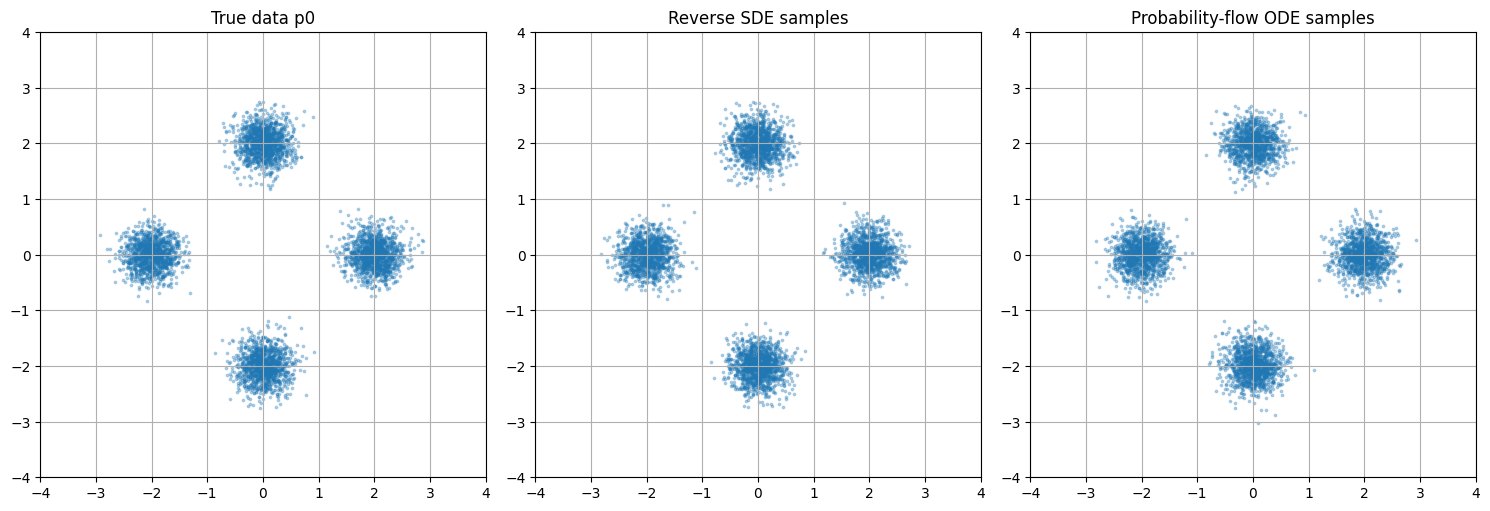

In [11]:
def reverse_sde_sampler(score_fn, n_samples, beta, T, n_steps, xT=None):
    """
    Reverse SDE sampler for constant-beta VP/OU.
    score_fn(x,t) returns score (N,2).
    """
    dt = T / n_steps
    if xT is None:
        x = np.random.randn(n_samples, 2)  # approximate p_T as N(0,I)
    else:
        x = xT.copy()

    for k in range(n_steps):
        t = T - k*dt
        s = score_fn(x, t)
        x = x + (0.5*beta*x + beta*s) * dt + np.sqrt(beta*dt) * np.random.randn(*x.shape)
    return x

def prob_flow_ode_sampler(score_fn, n_samples, beta, T, n_steps, xT=None):
    """
    Probability-flow ODE sampler (Euler) for constant-beta VP/OU.
    """
    dt = T / n_steps
    if xT is None:
        x = np.random.randn(n_samples, 2)
    else:
        x = xT.copy()

    for k in range(n_steps):
        t = T - k*dt
        s = score_fn(x, t)
        x = x + (0.5*beta*x + 0.5*beta*s) * dt
    return x

def sliced_w2(X, Y, n_proj=100, seed=0):
    """
    Approximate 2-Wasserstein via sliced Wasserstein (random 1D projections).
    X,Y: (n,2)
    """
    rng = np.random.default_rng(seed)
    n = min(len(X), len(Y))
    X = X[:n]
    Y = Y[:n]
    vals = []
    for _ in range(n_proj):
        v = rng.normal(size=2)
        v = v / np.linalg.norm(v)
        x1 = np.sort(X @ v)
        y1 = np.sort(Y @ v)
        vals.append(np.mean((x1 - y1)**2))
    return float(np.sqrt(np.mean(vals)))

# Define exact score function for toy A
def exact_score_uncond(x, t):
    return gmm.logp_and_score(x, t, beta)[1]

# Generate reference data samples from p0
n_ref = 5000
x_data, _ = gmm.sample_x0(n_ref)

# Sample using reverse SDE and probability-flow ODE
n_gen = 5000
x_sde = reverse_sde_sampler(exact_score_uncond, n_samples=n_gen, beta=beta, T=T, n_steps=800)
x_ode = prob_flow_ode_sampler(exact_score_uncond, n_samples=n_gen, beta=beta, T=T, n_steps=800)

print("Sliced W2(data, SDE):", sliced_w2(x_data, x_sde, n_proj=100))
print("Sliced W2(data, ODE):", sliced_w2(x_data, x_ode, n_proj=100))

fig, axes = plt.subplots(1,3, figsize=(15,5))
axes[0].scatter(x_data[:,0], x_data[:,1], s=3, alpha=0.3)
axes[0].set_title("True data p0")
axes[0].set_aspect("equal"); axes[0].set_xlim(-4,4); axes[0].set_ylim(-4,4)

axes[1].scatter(x_sde[:,0], x_sde[:,1], s=3, alpha=0.3)
axes[1].set_title("Reverse SDE samples")
axes[1].set_aspect("equal"); axes[1].set_xlim(-4,4); axes[1].set_ylim(-4,4)

axes[2].scatter(x_ode[:,0], x_ode[:,1], s=3, alpha=0.3)
axes[2].set_title("Probability-flow ODE samples")
axes[2].set_aspect("equal"); axes[2].set_xlim(-4,4); axes[2].set_ylim(-4,4)

plt.tight_layout()
plt.show()


# 6) Conditional / unconditional / guided scores

We have labels $y\in\{0,1\}$ assigned to mixture components. Then:

- **Unconditional**
  $$
  p_t(x)=\sum_k \pi_k \mathcal{N}(x;\mu_k(t),s_t^2I).
  $$

- **Conditional**
  $$
  p_t(x\mid y)
  $$
  is the same mixture but restricted to components with label $y$, with renormalized weights.

---

## Classifier guidance

Classifier guidance uses:

$$
s_{\text{guided}}(x,t)
=
s_{\text{uncond}}(x,t)
+
w\,\nabla_x\log p(y\mid x,t).
$$

For the **optimal Bayes classifier**,

$$
\log p(y\mid x,t)
=
\log p_t(x\mid y)
+
\log p(y)
-
\log p_t(x).
$$

Taking $\nabla_x$:

$$
\nabla_x\log p(y\mid x,t)
=
s_{\text{cond}}(x,t\mid y)
-
s_{\text{uncond}}(x,t).
$$

So with the exact classifier:

$$
s_{\text{guided}}
=
(1-w)s_{\text{uncond}}
+
w\, s_{\text{cond}}.
$$

---

## Classifier-free guidance (CFG)

Given conditional and unconditional scores:

$$
s_{\text{cfg}}
=
(1+w)s_{\text{cond}}
-
w\, s_{\text{uncond}}.
$$

CFG strengthens conditional behavior and can overshoot for large $w$.

---

We will:
1) Visualize vector fields for $s_{\text{uncond}}$, $s_{\text{cond}}$, $s_{\text{guided}}$, $s_{\text{cfg}}$.
2) Sample conditional distributions using the reverse SDE driven by these scores.


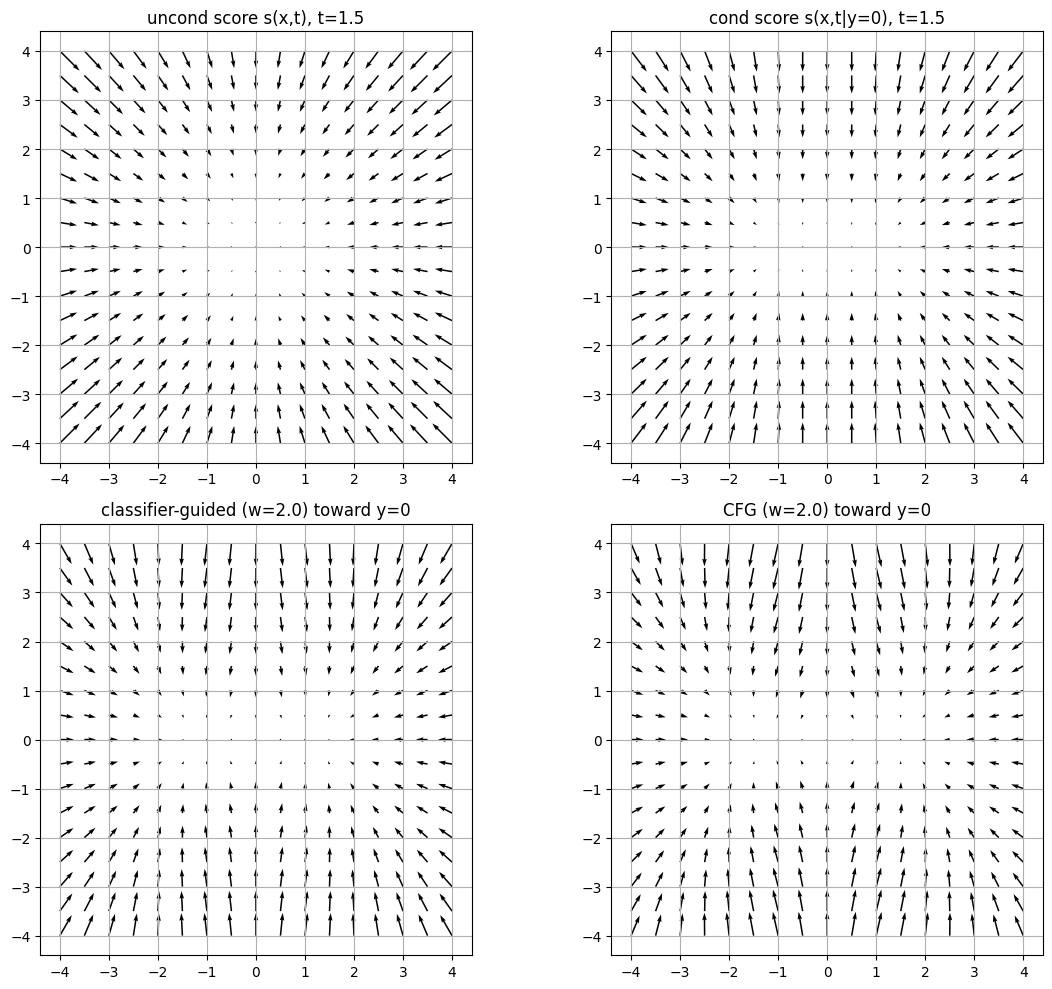

In [12]:
def exact_score_cond(x, t, y):
    return gmm.logp_and_score(x, t, beta, label=y)[1]

def exact_grad_log_p_y_given_x(x, t, y):
    # ∇ log p(y|x,t) = s_cond - s_uncond for Bayes-optimal classifier
    return exact_score_cond(x, t, y) - exact_score_uncond(x, t)

def guided_score_classifier(x, t, y, w):
    return exact_score_uncond(x, t) + w * exact_grad_log_p_y_given_x(x, t, y)

def guided_score_cfg(x, t, y, w):
    return (1+w) * exact_score_cond(x, t, y) - w * exact_score_uncond(x, t)

# Visualize fields at a medium noise time
t_vis = 1.5
xs, ys, X, Y, grid_pts = make_grid(-4, 4, n=81)

s_u = exact_score_uncond(grid_pts, t_vis)
s_c0 = exact_score_cond(grid_pts, t_vis, y=0)
s_c1 = exact_score_cond(grid_pts, t_vis, y=1)

w = 2.0
s_guid0 = guided_score_classifier(grid_pts, t_vis, y=0, w=w)
s_cfg0 = guided_score_cfg(grid_pts, t_vis, y=0, w=w)

def to_field(s):
    return s[:,0].reshape(X.shape), s[:,1].reshape(X.shape)

Uu, Vu = to_field(s_u)
Uc0, Vc0 = to_field(s_c0)
Ug0, Vg0 = to_field(s_guid0)
Ucfg0, Vcfg0 = to_field(s_cfg0)

fig, axes = plt.subplots(2,2, figsize=(12,10))
quiver_field(axes[0,0], X, Y, Uu, Vu, stride=5, title=f"uncond score s(x,t), t={t_vis}")
quiver_field(axes[0,1], X, Y, Uc0, Vc0, stride=5, title=f"cond score s(x,t|y=0), t={t_vis}")
quiver_field(axes[1,0], X, Y, Ug0, Vg0, stride=5, title=f"classifier-guided (w={w}) toward y=0")
quiver_field(axes[1,1], X, Y, Ucfg0, Vcfg0, stride=5, title=f"CFG (w={w}) toward y=0")
plt.tight_layout()
plt.show()


## Guided reverse sampling (conditional generation)

We can generate samples biased toward class $y$ by using guided scores in the reverse SDE.

We'll compare:
- unconditional generation,
- classifier guidance,
- CFG guidance,

for $y=0$, a moderate noise schedule $T=5$, and several guidance strengths $w$.

We measure similarity to the **true conditional data** $p_0(x\mid y)$ using sliced $W_2$, and also show scatter.


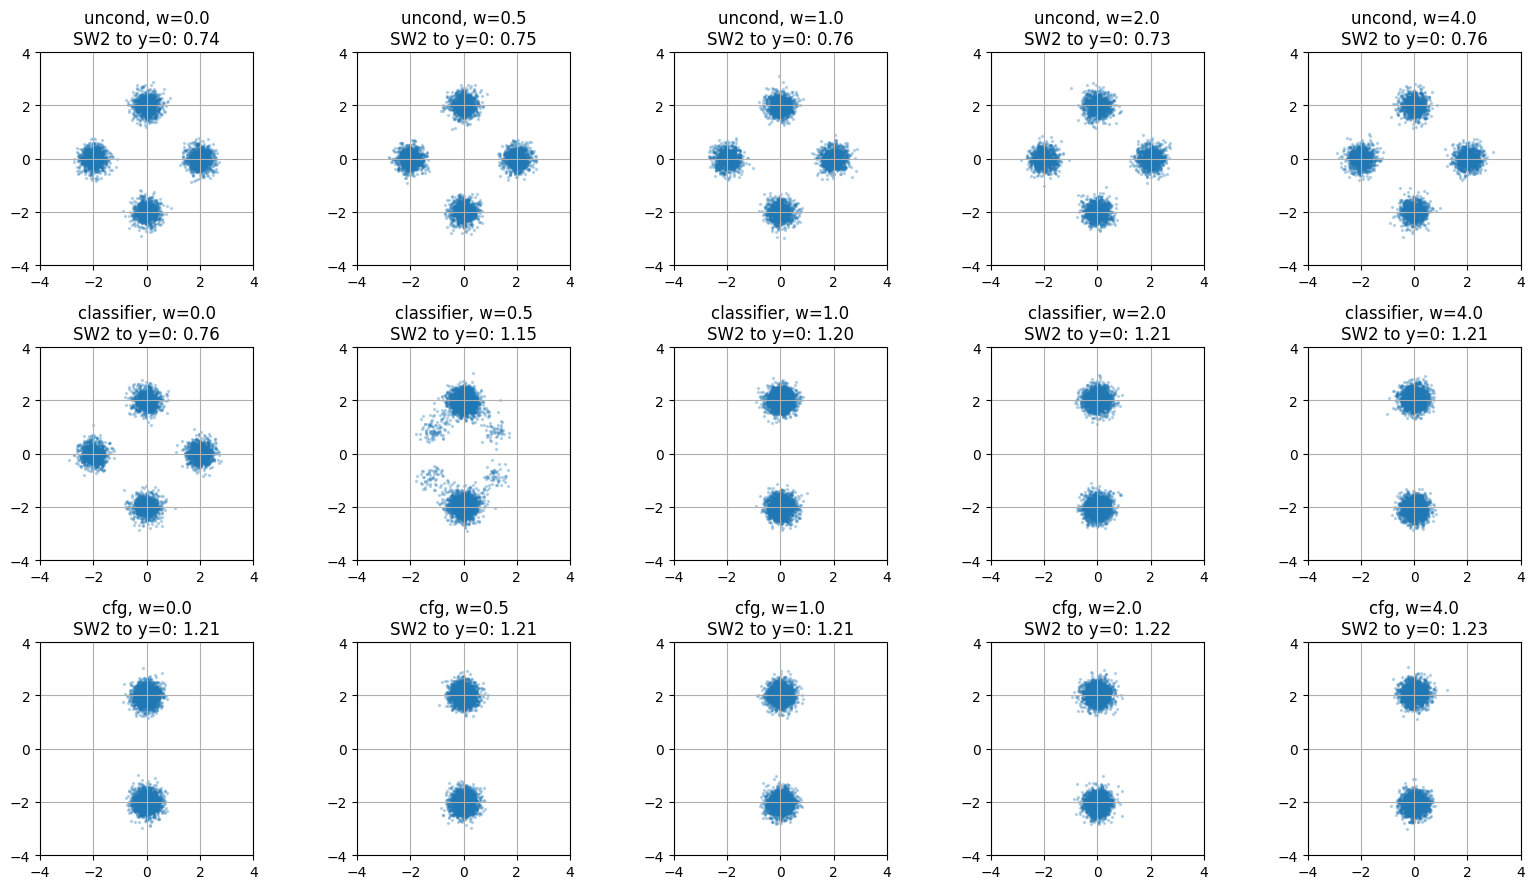

In [ ]:
def reverse_sde_sampler_guided(score_fn_typed, n_samples, beta, T, n_steps):
    dt = T / n_steps
    x = np.random.randn(n_samples, 2)
    for k in range(n_steps):
        t = T - k*dt
        s = score_fn_typed(x, t)
        x = x + (0.5*beta*x + beta*s) * dt + np.sqrt(beta*dt) * np.random.randn(*x.shape)
    return x

# True conditional data at t=0
n_ref = 5000
x0_all, k = gmm.sample_x0(n_ref)
y_all = labels[k]
x0_y0 = x0_all[y_all == 0]
x0_y1 = x0_all[y_all == 1]

def make_score_fn(kind, y, w):
    if kind == "uncond":
        return lambda x,t: exact_score_uncond(x,t)
    if kind == "classifier":
        return lambda x,t: guided_score_classifier(x,t,y=y,w=w)
    if kind == "cfg":
        return lambda x,t: guided_score_cfg(x,t,y=y,w=w)
    raise ValueError("unknown kind")

kinds = ["uncond", "classifier", "cfg"]
ws = [0.0, 0.5, 1.0, 2.0, 4.0]
n_gen = 4000
n_steps = 800

fig, axes = plt.subplots(len(kinds), len(ws), figsize=(3.2*len(ws), 3.0*len(kinds)))

for i, kind in enumerate(kinds):
    for j, w in enumerate(ws):
        if kind == "uncond":
            score_fn = make_score_fn(kind, y=0, w=0.0)
        else:
            score_fn = make_score_fn(kind, y=0, w=w)
        xg = reverse_sde_sampler_guided(score_fn, n_samples=n_gen, beta=beta, T=T, n_steps=n_steps)

        # metric vs true conditional class y=0
        dist = sliced_w2(x0_y0, xg, n_proj=80, seed=42)
        axes[i,j].scatter(xg[:,0], xg[:,1], s=2, alpha=0.25)
        axes[i,j].set_xlim(-4,4); axes[i,j].set_ylim(-4,4)
        axes[i,j].set_aspect("equal")
        axes[i,j].set_title(f"{kind}, w={w}\nSW2 to y=0: {dist:.2f}")

plt.tight_layout()
plt.show()


# 7) Divergence and curl of score fields (and why curl matters)

For a true score field,

$$
s(x,t)=\nabla_x \log p_t(x),
$$

the curl is zero (in smooth regions):

$$
\nabla\times s
=
\nabla\times \nabla \log p_t
\equiv 0.
$$

So **exact scores** should be curl-free up to numerical error.

However, *empirical scores* (KDE / finite samples) can exhibit small nonzero curl due to:
- finite sampling noise,
- bandwidth mismatch,
- discretization artifacts.

We'll compute:
- divergence $\nabla\cdot s$,
- scalar curl $\nabla\times s = \partial_x s_y - \partial_y s_x$,

and visualize these maps for:
1) exact score,
2) KDE score (finite $n$).

We will also plot a **pure rotation drift field**

$$
v(x)
=
\omega
\begin{pmatrix}
-y\\
x
\end{pmatrix}
=
\omega J x,
$$

which has:
- zero divergence,
- constant nonzero curl $= 2\omega$.

This is important because in **rotating internal dynamics**, the generator is *not* a gradient flow.


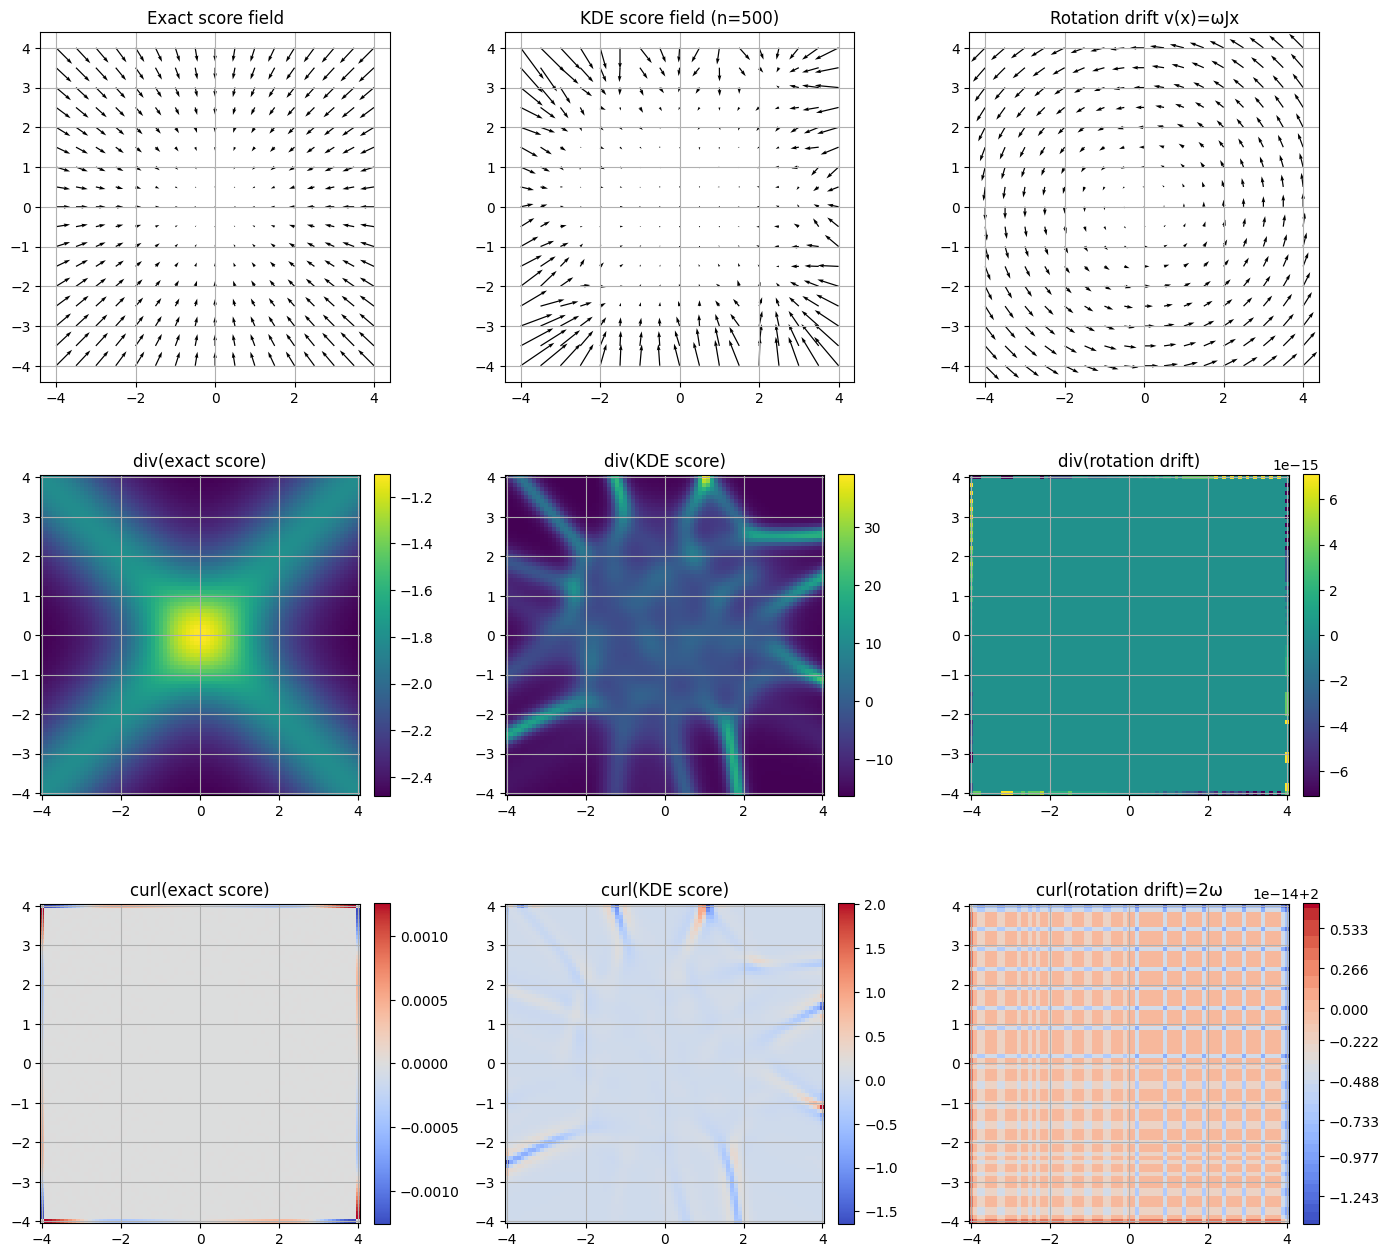

Exact score curl stats: mean abs 1.8237704858763297e-05 max abs 0.0012647969132787429
KDE score curl stats:   mean abs 0.04433825076591937 max abs 2.0172355025934454
Rotation curl stats:    mean 1.9999999999999984 should be about 2.0


In [14]:
# Compute exact score divergence/curl at some t
t_dc = 1.5
xs, ys, X, Y, grid_pts = make_grid(-4, 4, n=81)
_, s_exact = gmm.logp_and_score(grid_pts, t_dc, beta)
Ue = s_exact[:,0].reshape(X.shape)
Ve = s_exact[:,1].reshape(X.shape)
div_e, curl_e = divergence_and_curl(xs, ys, Ue, Ve)

# KDE score divergence/curl
n_kde = 500
h = 0.35
xt, _, _ = gmm.sample_xt(n_kde, t_dc, beta)
_, s_kde = kde_logp_and_score(grid_pts, xt, h=h)
Uk = s_kde[:,0].reshape(X.shape)
Vk = s_kde[:,1].reshape(X.shape)
div_k, curl_k = divergence_and_curl(xs, ys, Uk, Vk)

# Pure rotation drift field for comparison
omega = 1.0
Vx = -omega * Y
Vy =  omega * X
div_rot, curl_rot = divergence_and_curl(xs, ys, Vx, Vy)

fig, axes = plt.subplots(3, 3, figsize=(14, 13))

# Row 1: vector fields
quiver_field(axes[0,0], X, Y, Ue, Ve, stride=5, title="Exact score field")
quiver_field(axes[0,1], X, Y, Uk, Vk, stride=5, title=f"KDE score field (n={n_kde})")
quiver_field(axes[0,2], X, Y, Vx, Vy, stride=5, title="Rotation drift v(x)=ωJx")

# Row 2: divergence
plot_scalar(axes[1,0], X, Y, div_e, title="div(exact score)")
plot_scalar(axes[1,1], X, Y, div_k, title="div(KDE score)")
plot_scalar(axes[1,2], X, Y, div_rot, title="div(rotation drift)")

# Row 3: curl
plot_scalar(axes[2,0], X, Y, curl_e, title="curl(exact score)", cmap="coolwarm")
plot_scalar(axes[2,1], X, Y, curl_k, title="curl(KDE score)", cmap="coolwarm")
plot_scalar(axes[2,2], X, Y, curl_rot, title="curl(rotation drift)=2ω", cmap="coolwarm")

plt.tight_layout()
plt.show()

print("Exact score curl stats: mean abs", float(np.mean(np.abs(curl_e))), "max abs", float(np.max(np.abs(curl_e))))
print("KDE score curl stats:   mean abs", float(np.mean(np.abs(curl_k))), "max abs", float(np.max(np.abs(curl_k))))
print("Rotation curl stats:    mean", float(np.mean(curl_rot)), "should be about", 2*omega)


# 8) Toy system B: dynamic trajectories with internal rotation

Now we introduce a second time axis: **internal time** $u$, distinct from diffusion time $t$.

## Clean internal dynamics (exact rotation)

We define trajectories:

$$
x(u) = R(\omega u)\,x(0),\qquad u=0,\dots,T_{\text{int}}-1.
$$

So the clean distribution at each internal time $u$ is just a rotated version of $p_0$.

## Diffusion-time corruption per frame

For each internal time $u$, we apply OU corruption independently:

$$
x_t(u)=\alpha(t)x(u)+\sigma(t)z,\quad z\sim\mathcal{N}(0,I),
$$

so we have marginals $p_t(x\mid u)$. Because OU noise is isotropic, $p_t(\cdot\mid u)$ remains a rotated version.

---

### Score field with two times

Define:

$$
s(x,u,t) = \nabla_x\log p_t(x\mid u).
$$

We will visualize $s(\cdot,u,t)$ for multiple $u$ and $t$, and study how it propagates across $u$.

---

## Propagation operator $P$ across internal time

Because the density rotates, the score transforms covariantly. If

$$
p_u(x)=p_0(R^{-u}x),
$$

then

$$
\nabla\log p_u(x)=R^u \left[\nabla\log p_0(R^{-u}x)\right].
$$

This suggests an operator acting on vector fields:

$$
(Pv)(x)=R\,v(R^{-1}x).
$$

For rotation by a small angle $\Delta\theta$, $P\approx e^{\Delta\theta \mathcal{G}}$ where the generator $\mathcal{G}$ is the infinitesimal rotation operator (Koopman/transport generator).

We will:
1) generate trajectory data,
2) compute score fields $s(\cdot,u,t)$,
3) empirically estimate the rotation $R$ from data (Procrustes),
4) test $s(\cdot,u,t)\approx P[s(\cdot,u-1,t)]$.


## Koopman transport generator

For a dynamical system

$$
\frac{dx}{du}=F(x),
$$

the **Koopman operator** evolves observables (functions) via

$$
(U^u f)(x)=f(\Phi^u(x)),
$$

where $\Phi^u$ is the flow.

The **Koopman generator** is the infinitesimal operator

$$
\mathcal{G}f(x)
=
\left.\frac{d}{du}U^u f(x)\right|_{u=0}
=
F(x)\cdot\nabla f(x).
$$

It is a **transport operator**: it differentiates $f$ along the vector field $F$.

Example (rotation $F(x)=\omega Jx$):

$$
\mathcal{G}f(x)=(\omega Jx)\cdot\nabla f(x),
$$

which generates infinitesimal rotation of observables.

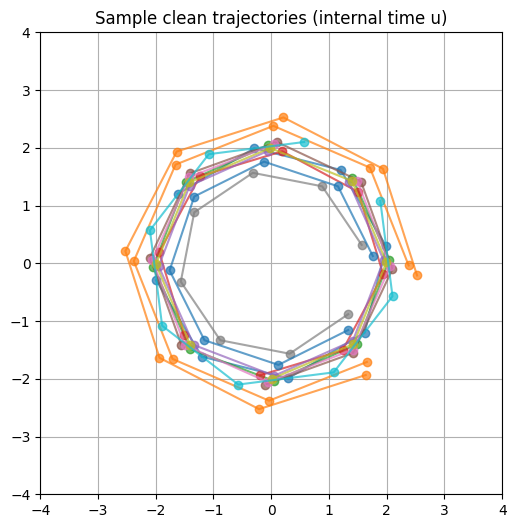

In [15]:
def generate_rotating_trajectories(gmm: IsotropicGMM2D, n_traj, T_int, omega_step):
    """
    Generate clean trajectories x(u) = R(omega_step * u) x0.
    Returns:
      X_clean: (n_traj, T_int, 2)
      labels per trajectory's component at u=0 (for reference)
    """
    x0, k = gmm.sample_x0(n_traj)
    X = np.zeros((n_traj, T_int, 2))
    for u in range(T_int):
        R = rotmat(omega_step * u)
        X[:, u, :] = x0 @ R.T
    return X, k

def corrupt_frames_ou(X_clean, t, beta):
    """
    Apply OU corruption per frame: x_t = alpha x_clean + sigma z.
    X_clean: (n, T_int, 2)
    """
    a, sig = alpha_sigma(t, beta)
    noise = np.random.randn(*X_clean.shape)
    return a * X_clean + sig * noise

# Build trajectory dataset
T_int = 8
omega_step = 2*np.pi / T_int  # one full rotation over the trajectory

n_traj = 3000
X_clean, k0 = generate_rotating_trajectories(gmm, n_traj=n_traj, T_int=T_int, omega_step=omega_step)

# Visualize a few clean trajectories
fig, ax = plt.subplots(1,1, figsize=(6,6))
for i in range(12):
    ax.plot(X_clean[i,:,0], X_clean[i,:,1], marker="o", alpha=0.7)
ax.set_title("Sample clean trajectories (internal time u)")
ax.set_aspect("equal")
ax.set_xlim(-4,4); ax.set_ylim(-4,4)
plt.show()


## Exact score for $p_t(x\mid u)$

Because the internal dynamics is a deterministic rotation of the initial mixture, the distribution at internal time $u$ is a rotated mixture:

- component means at time $u$:
  $$
  \mu_k^{(u)} = R(\omega u)\mu_k
  $$

- after OU diffusion time $t$: means become
  $$
  \alpha(t)\mu_k^{(u)},
  $$
  and covariance becomes
  $$
  s_t^2 I.
  $$

So the **exact score** is computed using the same GMM formula, but with rotated means.

We define the convenience function:

$$
s(x,u,t)=\nabla_x\log p_t(x\mid u),
$$

for the unconditional mixture at internal time $u$.


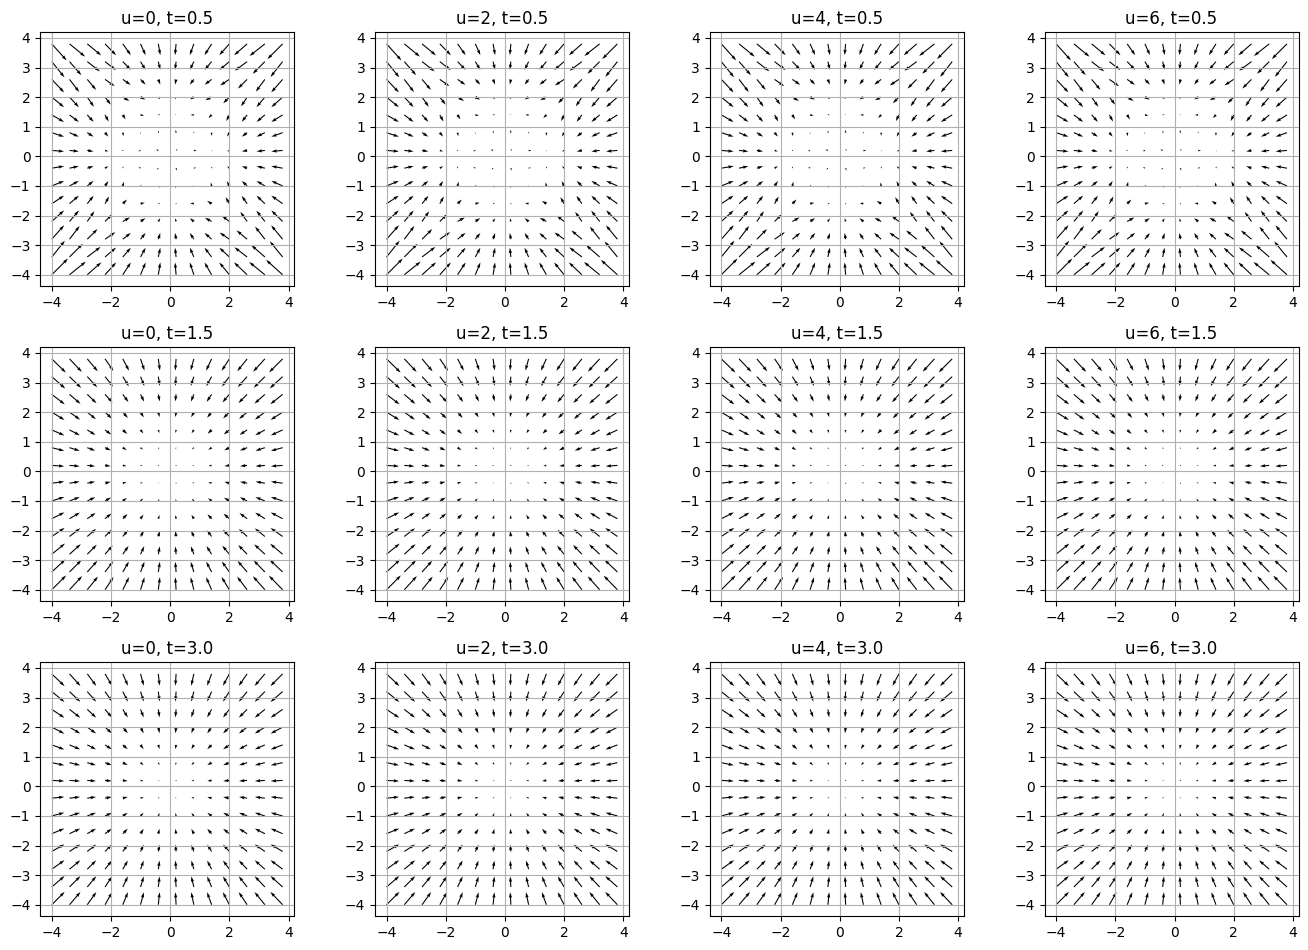

In [16]:
def gmm_score_internal_time(x, u, t, beta, gmm: IsotropicGMM2D, omega_step):
    """
    Unconditional score at diffusion time t and internal time u,
    assuming clean means are rotated by R(omega_step * u).
    """
    x = np.atleast_2d(x)
    a, sig = alpha_sigma(t, beta)
    s2 = (a**2) * (gmm.sigma0**2) + sig**2

    R = rotmat(omega_step * u)
    means_u = gmm.means0 @ R.T           # rotate clean means
    means_t = a * means_u               # OU scaling

    # compute responsibilities for mixture with these means
    x2 = np.sum(x**2, axis=1, keepdims=True)
    m2 = np.sum(means_t**2, axis=1, keepdims=True).T
    xm = x @ means_t.T
    d2 = x2 + m2 - 2*xm

    log_norm = -np.log(2*np.pi*s2)
    log_phi = np.log(gmm.weights[None, :]) + log_norm - 0.5 * d2 / s2
    logp = logsumexp(log_phi, axis=1)
    resp = np.exp(log_phi - logp[:,None])
    mean_post = resp @ means_t
    score = (mean_post - x) / s2
    return score

# Visualize score fields across u for multiple diffusion times t
ts_show = [0.5, 1.5, 3.0]
us_show = [0, 2, 4, 6]

xs, ys, X, Y, grid_pts = make_grid(-4,4,n=81)

fig, axes = plt.subplots(len(ts_show), len(us_show), figsize=(3.4*len(us_show), 3.2*len(ts_show)))
for i, t in enumerate(ts_show):
    for j, u in enumerate(us_show):
        s = gmm_score_internal_time(grid_pts, u=u, t=t, beta=beta, gmm=gmm, omega_step=omega_step)
        U = s[:,0].reshape(X.shape)
        V = s[:,1].reshape(X.shape)
        quiver_field(axes[i,j], X, Y, U, V, stride=6, title=f"u={u}, t={t}")
plt.tight_layout()
plt.show()


# 9) Empirical propagation operator $P$: estimating rotation from trajectory data

We want an operator $P$ such that

$$
s(\cdot,u,t)\approx P[s(\cdot,u-1,t)].
$$

For pure rotation by $R$, the natural pushforward operator on vector fields is:

$$
(Pv)(x)=R\,v(R^{-1}x).
$$

We will:
1) Pick a diffusion time $t$.
2) Corrupt trajectory frames to get noisy samples at each $u$: $x_t(u)$.
3) Use paired samples $(x_t(u-1), x_t(u))$ to estimate the best rotation matrix $\hat R$ via **orthogonal Procrustes**.
4) Apply $\hat P$ to the field at $u-1$ and compare to the field at $u$.

---

### Orthogonal Procrustes (rotation fit)

Given paired matrices $A,B\in\mathbb{R}^{n\times 2}$, find orthogonal $R$ minimizing

$$
\|AR-B\|_F.
$$

Compute the SVD of

$$
A^\top B = U\Sigma V^\top,
$$

then the optimal rotation is

$$
R = U V^\top.
$$


Estimated rotation angle per step (rad): -0.685639448055344 true: 0.7853981633974483
Field prediction MSE=4.0162e+00, normalized=3.8457e-01


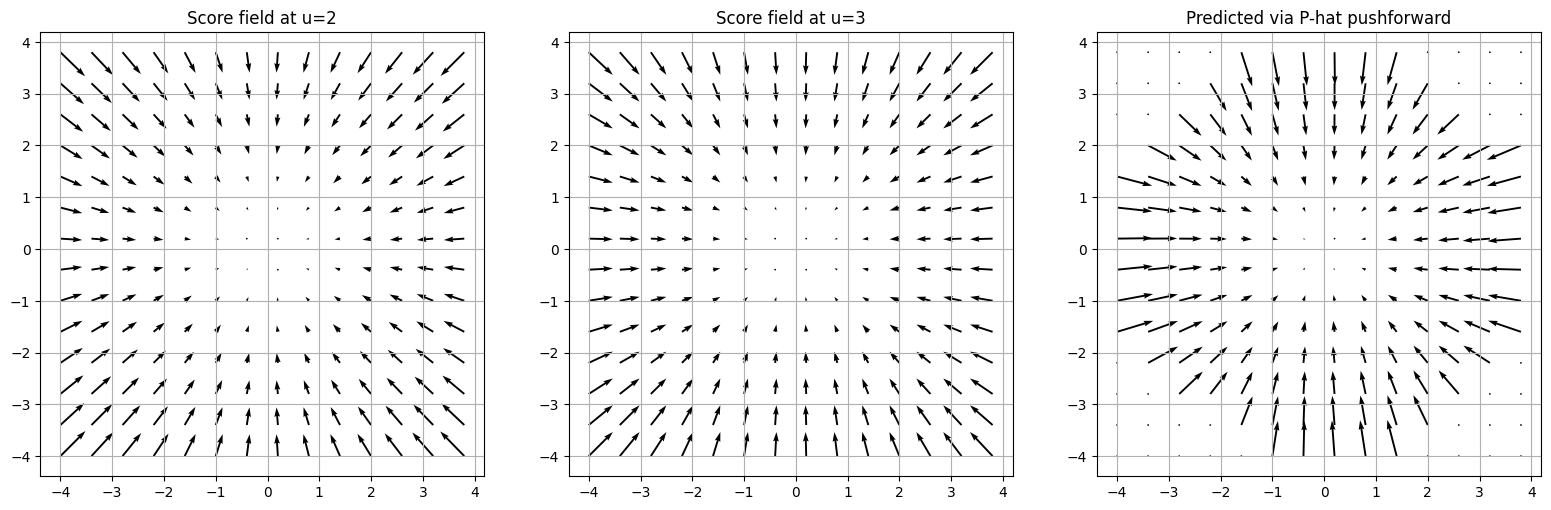

In [17]:
def procrustes_rotation(A, B):
    """
    Fit rotation R (2x2 orthogonal with det=+1) minimizing ||A R - B||_F.
    A,B: (n,2) paired data (mean-centered recommended).
    """
    A0 = A - A.mean(axis=0, keepdims=True)
    B0 = B - B.mean(axis=0, keepdims=True)
    M = A0.T @ B0
    U, _, Vt = np.linalg.svd(M)
    R = U @ Vt
    # enforce det=+1
    if np.linalg.det(R) < 0:
        U[:, -1] *= -1
        R = U @ Vt
    return R

def apply_field_pushforward(U_prev, V_prev, xs, ys, R):
    """
    Given a vector field (U_prev,V_prev) on grid (xs,ys),
    produce field (U_pred,V_pred) defined by (Pv)(x)=R v(R^{-1}x).
    
    Uses bilinear interpolation.
    """
    # Build interpolators for U and V on (y,x) axes order used by meshgrid.
    interpU = RegularGridInterpolator((ys, xs), U_prev, bounds_error=False, fill_value=0.0)
    interpV = RegularGridInterpolator((ys, xs), V_prev, bounds_error=False, fill_value=0.0)

    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")
    pts = np.stack([Xg.ravel(), Yg.ravel()], axis=1)  # (G,2)

    # preimage point: R^{-1} x = R^T x for rotation
    pre = pts @ R  # since pts are row vectors; multiply by R gives pts*R = (R^T x)^T? Let's check carefully:
    # If we want pre = R^{-1} x, with x as column, pre = R^T x.
    # With row representation, x_row = x^T; then pre_row = x_row R.
    # So pts @ R is correct.

    # interpolators expect (y,x)
    pre_yx = np.stack([pre[:,1], pre[:,0]], axis=1)
    u0 = interpU(pre_yx)
    v0 = interpV(pre_yx)
    vec0 = np.stack([u0, v0], axis=1)  # (G,2)

    # pushforward: R * vec0 (column); with rows: vec_row @ R^T
    vec_pred = vec0 @ R.T
    U_pred = vec_pred[:,0].reshape(Xg.shape)
    V_pred = vec_pred[:,1].reshape(Xg.shape)
    return U_pred, V_pred

# Choose a diffusion time and corrupt frames
tP = 1.5
X_noisy = corrupt_frames_ou(X_clean, t=tP, beta=beta)  # (n_traj,T_int,2)

# Estimate rotation between consecutive internal frames for a few u
xs, ys, Xg, Yg, grid_pts = make_grid(-4,4,n=81)

u_target = 3  # compare u-1 -> u
A = X_noisy[:, u_target-1, :]
B = X_noisy[:, u_target, :]
R_hat = procrustes_rotation(A, B)

theta_hat = np.arctan2(R_hat[1,0], R_hat[0,0])
print("Estimated rotation angle per step (rad):", theta_hat, "true:", omega_step)

# Compare score fields: exact s(u-1,tP) and s(u,tP)
s_prev = gmm_score_internal_time(grid_pts, u=u_target-1, t=tP, beta=beta, gmm=gmm, omega_step=omega_step)
s_curr = gmm_score_internal_time(grid_pts, u=u_target, t=tP, beta=beta, gmm=gmm, omega_step=omega_step)
U_prev = s_prev[:,0].reshape(Xg.shape); V_prev = s_prev[:,1].reshape(Xg.shape)
U_curr = s_curr[:,0].reshape(Xg.shape); V_curr = s_curr[:,1].reshape(Xg.shape)

# Pushforward prediction using R_hat
U_pred, V_pred = apply_field_pushforward(U_prev, V_prev, xs, ys, R_hat)

# Compare errors
err = np.mean((U_pred - U_curr)**2 + (V_pred - V_curr)**2)
norm = np.mean(U_curr**2 + V_curr**2)
print(f"Field prediction MSE={err:.4e}, normalized={err/(norm+1e-12):.4e}")

fig, axes = plt.subplots(1,3, figsize=(16,5))
quiver_field(axes[0], Xg, Yg, U_prev, V_prev, stride=6, title=f"Score field at u={u_target-1}")
quiver_field(axes[1], Xg, Yg, U_curr, V_curr, stride=6, title=f"Score field at u={u_target}")
quiver_field(axes[2], Xg, Yg, U_pred, V_pred, stride=6, title="Predicted via P-hat pushforward")
plt.tight_layout()
plt.show()


## Generator viewpoint (Koopman / transport intuition)

For a deterministic flow $x \mapsto \Phi_\Delta(x)$ (here rotation), the Koopman operator on scalar functions is:

$$
(U_\Delta f)(x)=f(\Phi_{-\Delta}(x)).
$$

For rotation by $\Delta\theta$, $\Phi_\Delta(x)=R(\Delta\theta)x$. The infinitesimal generator is:

$$
\mathcal{L}f
=
\left.\frac{d}{d\Delta}(U_\Delta f)\right|_{\Delta=0}
=
-(\omega J x)\cdot \nabla f,
$$

which in polar coordinates is $\mathcal{L}=\omega\,\partial_\theta$.

Eigenfunctions are angular harmonics $e^{ik\theta}$ with eigenvalues $ik\omega$.

We'll demonstrate this spectrally in the next section by Fourier decomposition in angle.

Before that, let's quantify how well the empirical rotation estimate works *for all $u$*.


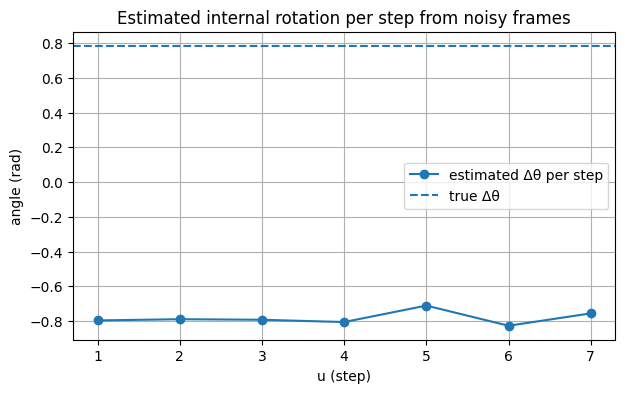

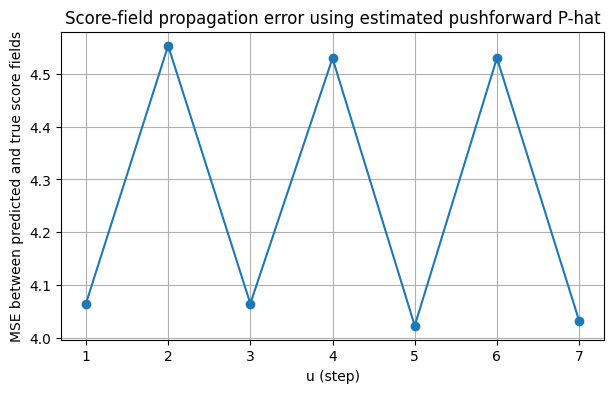

In [18]:
def field_mse(U1,V1,U2,V2):
    return float(np.mean((U1-U2)**2 + (V1-V2)**2))

tP = 1.5
X_noisy = corrupt_frames_ou(X_clean, t=tP, beta=beta)

xs, ys, Xg, Yg, grid_pts = make_grid(-4,4,n=81)

mses = []
angles_hat = []
for u in range(1, T_int):
    A = X_noisy[:,u-1,:]
    B = X_noisy[:,u,:]
    R_hat = procrustes_rotation(A,B)
    theta_hat = np.arctan2(R_hat[1,0], R_hat[0,0])
    angles_hat.append(theta_hat)

    s_prev = gmm_score_internal_time(grid_pts, u=u-1, t=tP, beta=beta, gmm=gmm, omega_step=omega_step)
    s_curr = gmm_score_internal_time(grid_pts, u=u,   t=tP, beta=beta, gmm=gmm, omega_step=omega_step)
    U_prev = s_prev[:,0].reshape(Xg.shape); V_prev = s_prev[:,1].reshape(Xg.shape)
    U_curr = s_curr[:,0].reshape(Xg.shape); V_curr = s_curr[:,1].reshape(Xg.shape)

    U_pred, V_pred = apply_field_pushforward(U_prev,V_prev,xs,ys,R_hat)
    mses.append(field_mse(U_pred,V_pred,U_curr,V_curr))

plt.figure(figsize=(7,4))
plt.plot(range(1,T_int), angles_hat, marker="o", label="estimated Δθ per step")
plt.axhline(omega_step, linestyle="--", label="true Δθ")
plt.title("Estimated internal rotation per step from noisy frames")
plt.xlabel("u (step)")
plt.ylabel("angle (rad)")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(range(1,T_int), mses, marker="o")
plt.title("Score-field propagation error using estimated pushforward P-hat")
plt.xlabel("u (step)")
plt.ylabel("MSE between predicted and true score fields")
plt.show()


# 10) Spectral viewpoint: Fourier in angle and damping with diffusion time

Rotation suggests using **polar coordinates** $(r,\theta)$.
We will study how diffusion time $t$ damps **high-frequency angular modes**.

## Concrete implementation (Fourier series on a circle)

Pick a radius $r=r^*$ (near the ring where the mixture lives). 
Evaluate the density:

$$
p_t(r^*,\theta)
=
p_t\big(x=(r^*\cos\theta,r^*\sin\theta)\big).
$$

Compute Fourier coefficients:

$$
\hat p_k(t)
=
\frac{1}{2\pi}
\int_0^{2\pi}
p_t(r^*,\theta)\,e^{-ik\theta}\,d\theta.
$$

In discrete form we use FFT. We then examine:
- magnitude $|\hat p_k(t)|$ vs mode $k$,
- how it changes as $t$ increases.

**Expectation:** As noise increases (larger $\sigma(t)$), the density becomes smoother and more isotropic, so higher $|k|$ modes are suppressed.

We also compute a Fourier decomposition of the angular score component:

$$
s_\theta = s \cdot e_\theta,
\qquad
e_\theta = (-\sin\theta,\cos\theta).
$$

---

## Laplace transform viewpoint (concrete)

For OU, moments satisfy linear ODEs:

$$
\frac{d}{dt}m(t)=-\frac{\beta}{2}m(t),
\qquad
\frac{d}{dt}V(t)=-\beta V(t)+\beta I.
$$

We can solve the covariance ODE with Laplace transform:

$$
\mathcal{L}\{V\}(s)
=
\frac{V(0)}{s+\beta}
+
\frac{\beta}{s(s+\beta)}I
\Rightarrow
V(t)=e^{-\beta t}V(0) + (1-e^{-\beta t})I.
$$

We'll verify this numerically from simulated trajectories.


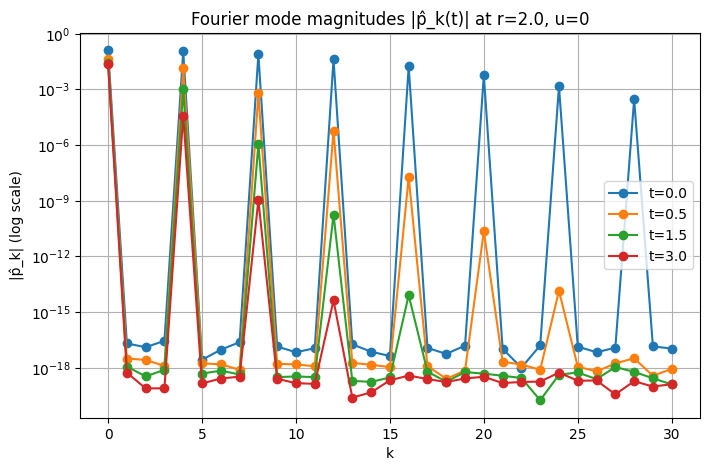

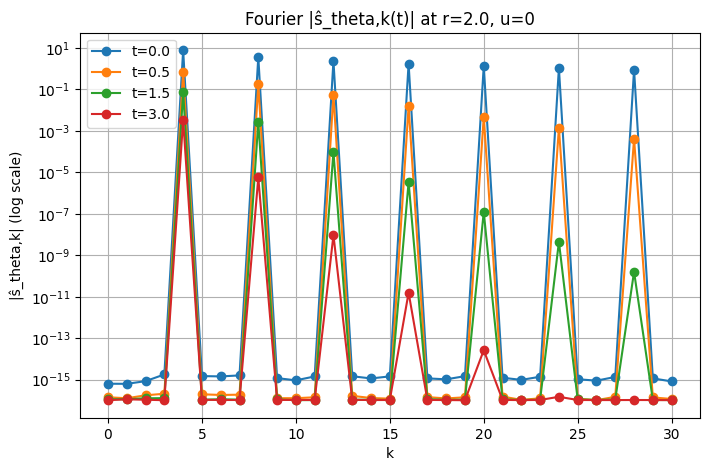

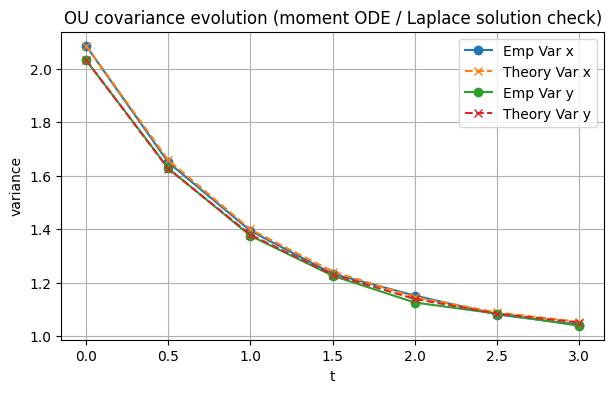

In [19]:
def gmm_logp_internal_time(x, u, t, beta, gmm: IsotropicGMM2D, omega_step):
    """
    Log density p_t(x|u) for rotating-mixture toy at internal time u.
    """
    x = np.atleast_2d(x)
    a, sig = alpha_sigma(t, beta)
    s2 = (a**2)*(gmm.sigma0**2) + sig**2
    R = rotmat(omega_step * u)
    means_u = gmm.means0 @ R.T
    means_t = a * means_u

    x2 = np.sum(x**2, axis=1, keepdims=True)
    m2 = np.sum(means_t**2, axis=1, keepdims=True).T
    xm = x @ means_t.T
    d2 = x2 + m2 - 2*xm

    log_norm = -np.log(2*np.pi*s2)
    log_phi = np.log(gmm.weights[None,:]) + log_norm - 0.5*d2/s2
    return logsumexp(log_phi, axis=1)

# Fourier on a circle
r_star = 2.0
n_theta = 512
thetas = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
circle_pts = np.stack([r_star*np.cos(thetas), r_star*np.sin(thetas)], axis=1)

ts_fourier = [0.0, 0.5, 1.5, 3.0]
u0 = 0

coeffs = []
for t in ts_fourier:
    logp = gmm_logp_internal_time(circle_pts, u=u0, t=t, beta=beta, gmm=gmm, omega_step=omega_step)
    p = np.exp(logp)
    # FFT (unnormalized); take magnitude
    c = np.fft.fft(p) / n_theta
    coeffs.append(c)

Kmax = 30
plt.figure(figsize=(8,5))
for t, c in zip(ts_fourier, coeffs):
    amp = np.abs(c[:Kmax+1])
    plt.semilogy(range(Kmax+1), amp, marker="o", label=f"t={t}")
plt.title(f"Fourier mode magnitudes |p̂_k(t)| at r={r_star}, u={u0}")
plt.xlabel("k")
plt.ylabel("|p̂_k| (log scale)")
plt.legend()
plt.show()

# Also look at angular score component s_theta and its Fourier modes
def angular_component_of_score(score_xy, theta):
    # score_xy: (N,2), theta: (N,)
    e_theta = np.stack([-np.sin(theta), np.cos(theta)], axis=1)
    return np.sum(score_xy * e_theta, axis=1)

coeffs_stheta = []
for t in ts_fourier:
    sxy = gmm_score_internal_time(circle_pts, u=u0, t=t, beta=beta, gmm=gmm, omega_step=omega_step)
    st = angular_component_of_score(sxy, thetas)
    c = np.fft.fft(st) / n_theta
    coeffs_stheta.append(c)

plt.figure(figsize=(8,5))
for t, c in zip(ts_fourier, coeffs_stheta):
    amp = np.abs(c[:Kmax+1])
    plt.semilogy(range(Kmax+1), amp + 1e-16, marker="o", label=f"t={t}")
plt.title(f"Fourier |ŝ_theta,k(t)| at r={r_star}, u={u0}")
plt.xlabel("k")
plt.ylabel("|ŝ_theta,k| (log scale)")
plt.legend()
plt.show()

# Laplace-transform / moment verification from simulated OU trajectories
# We'll simulate OU from the data distribution and estimate covariance vs t, compare to formula.

ts_mom = np.linspace(0, 3.0, 7)
n_sim = 20000
x0, _ = gmm.sample_x0(n_sim)

traj = simulate_forward_ou(x0, ts_mom, beta)

# empirical covariance vs t
cov_emp = []
for x in traj:
    cov_emp.append(np.cov(x.T))

cov_emp = np.array(cov_emp)  # (len(ts),2,2)

# theoretical covariance: V(t) = a^2 V0 + (1-a^2) I, but careful:
# For OU with alpha=exp(-beta t/2), variance from initial gets scaled by alpha^2,
# plus (1-exp(-beta t)) I.
V0 = np.cov(x0.T)
cov_th = []
for t in ts_mom:
    a, sig = alpha_sigma(t, beta)
    cov_th.append((a**2) * V0 + (sig**2) * np.eye(2))
cov_th = np.array(cov_th)

plt.figure(figsize=(7,4))
plt.plot(ts_mom, cov_emp[:,0,0], marker="o", label="Emp Var x")
plt.plot(ts_mom, cov_th[:,0,0], marker="x", linestyle="--", label="Theory Var x")
plt.plot(ts_mom, cov_emp[:,1,1], marker="o", label="Emp Var y")
plt.plot(ts_mom, cov_th[:,1,1], marker="x", linestyle="--", label="Theory Var y")
plt.title("OU covariance evolution (moment ODE / Laplace solution check)")
plt.xlabel("t")
plt.ylabel("variance")
plt.legend()
plt.show()


# 11) Research extensions (minimal but concrete)

This section is intentionally *research-ish*: it connects diffusion/score ideas to:
- Fluctuation–dissipation theorem (FDT)
- Landau-style order parameter / bifurcation intuition
- Replica method (minimal computation) via Random Energy Model (REM)

Each subsection includes:
- equations/intuition,
- a concrete calculation,
- at least one plot.

---

## 11.1 Fluctuation–dissipation theorem (FDT) in OU, and “score as force”

Consider 1D OU at equilibrium:

$$
dX_t = -\lambda X_t\,dt + \sqrt{2D}\,dW_t.
$$

Stationary density:

$$
p_{\text{eq}}(x)
\propto
\exp\!\left(-\frac{\lambda}{2D}x^2\right),
\qquad
\mathrm{Var}(X)=\frac{D}{\lambda}.
$$

Score:

$$
s(x)
=
\partial_x\log p_{\text{eq}}(x)
=
-\frac{\lambda}{D}x.
$$

Physical drift force is $F(x)=-\lambda x$, so:

$$
F(x) = D\, s(x).
$$

Thus, diffusion strength $D$ (temperature-like) scales the score into force.

---

### FDT statement (one form)

Let

$$
C(\tau)=\mathbb{E}[X_{t+\tau}X_t]
$$

at stationarity. For OU:

$$
C(\tau)
=
\frac{D}{\lambda}
e^{-\lambda|\tau|}.
$$

The linear response to a small impulse force at time 0 has kernel:

$$
R(\tau)
=
e^{-\lambda \tau}\mathbf{1}_{\tau\ge0}.
$$

One FDT form is:

$$
R(\tau)
=
-\frac{1}{D}\frac{d}{d\tau}C(\tau),
\qquad
\tau>0.
$$

We'll verify numerically by:
- estimating $C(\tau)$,
- estimating response $R(\tau)$ from simulations with a small impulse perturbation,
- comparing to the FDT prediction.


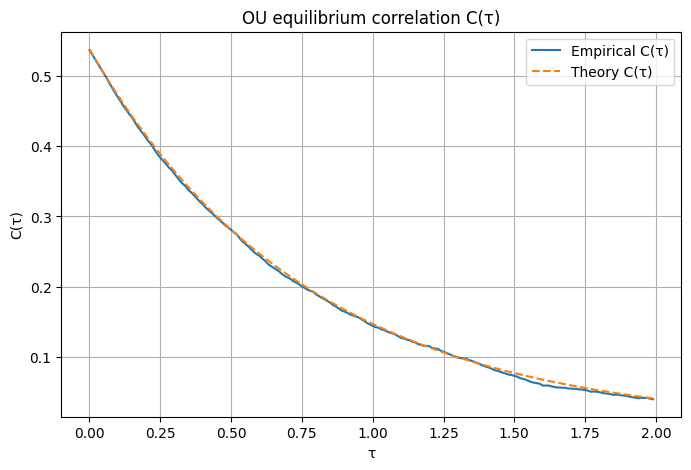

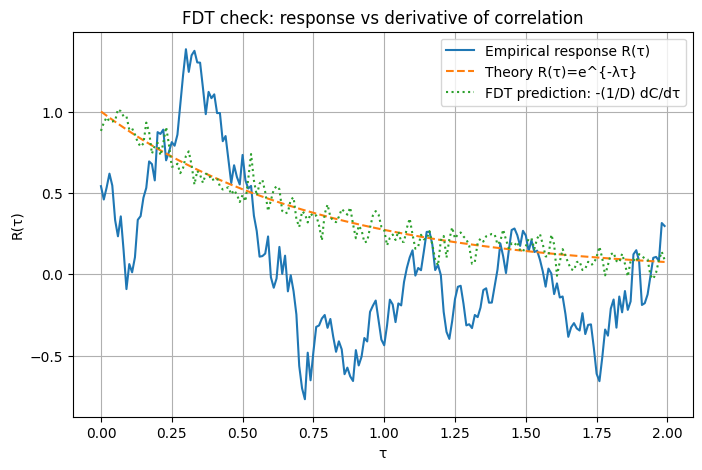

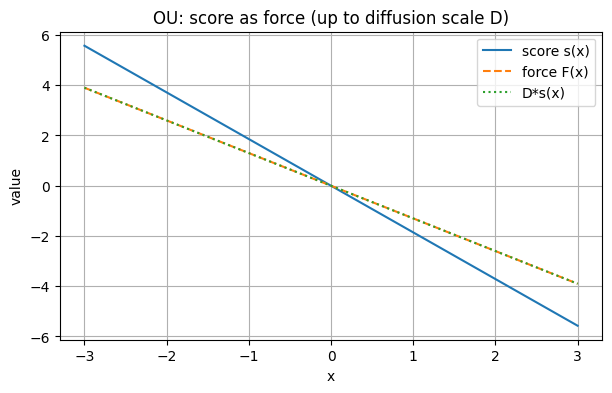

In [20]:
def simulate_ou_1d(n_paths, n_steps, dt, lam, D, x0=None, impulse=0.0):
    """
    Simulate 1D OU:
        dX = -lam X dt + sqrt(2D) dW
    If impulse != 0: add instantaneous kick at step 0: X <- X + impulse.
    """
    if x0 is None:
        # start from stationary distribution
        x = np.sqrt(D/lam) * np.random.randn(n_paths)
    else:
        x = np.array(x0, dtype=float).copy()
    if impulse != 0.0:
        x = x + impulse

    X = np.zeros((n_paths, n_steps+1))
    X[:,0] = x
    for k in range(n_steps):
        x = x + (-lam * x) * dt + np.sqrt(2*D*dt) * np.random.randn(n_paths)
        X[:,k+1] = x
    return X

lam = 1.3
D = 0.7
dt = 0.01
n_steps = 800
n_paths = 20000

# Correlation function C(tau)
X = simulate_ou_1d(n_paths, n_steps, dt, lam, D, impulse=0.0)
x0 = X[:,0]
taus = np.arange(0, 200)  # up to 200 steps
C_emp = np.array([np.mean(X[:,k] * x0) for k in taus])

tau_cont = taus * dt
C_th = (D/lam) * np.exp(-lam * tau_cont)

# Response function R(tau) via impulse
eps = 1e-2
X_imp = simulate_ou_1d(n_paths, n_steps, dt, lam, D, impulse=eps)
# response in mean: (E[X_imp(t)] - E[X(t)]) / eps
R_emp = (np.mean(X_imp[:,taus], axis=0) - np.mean(X[:,taus], axis=0)) / eps
R_th = np.exp(-lam * tau_cont)

# FDT prediction: R = -(1/D) dC/dtau
# use finite differences
dC_dtau = np.gradient(C_emp, dt)
R_fdt = -(1/D) * dC_dtau

plt.figure(figsize=(8,5))
plt.plot(tau_cont, C_emp, label="Empirical C(τ)")
plt.plot(tau_cont, C_th, linestyle="--", label="Theory C(τ)")
plt.title("OU equilibrium correlation C(τ)")
plt.xlabel("τ")
plt.ylabel("C(τ)")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(tau_cont, R_emp, label="Empirical response R(τ)")
plt.plot(tau_cont, R_th, linestyle="--", label="Theory R(τ)=e^{-λτ}")
plt.plot(tau_cont, R_fdt, linestyle=":", label="FDT prediction: -(1/D) dC/dτ")
plt.title("FDT check: response vs derivative of correlation")
plt.xlabel("τ")
plt.ylabel("R(τ)")
plt.legend()
plt.show()

# Score-as-force sanity: score(x) = -(lam/D)x
xs1 = np.linspace(-3,3,200)
score_stationary = -(lam/D) * xs1
force = -lam * xs1
plt.figure(figsize=(7,4))
plt.plot(xs1, score_stationary, label="score s(x)")
plt.plot(xs1, force, linestyle="--", label="force F(x)")
plt.plot(xs1, D*score_stationary, linestyle=":", label="D*s(x)")
plt.title("OU: score as force (up to diffusion scale D)")
plt.xlabel("x")
plt.ylabel("value")
plt.legend()
plt.show()


## 11.2 Landau-style analysis: an order parameter for “speciation/commitment”

We want a simple *order parameter* that captures “commitment” to one of two modes/classes.

Consider a 1D symmetric mixture:

$$
p(x)
=
\frac12\mathcal{N}(x;+\mu,\sigma^2)
+
\frac12\mathcal{N}(x;-\mu,\sigma^2).
$$

Define the **effective Landau potential**:

$$
F(x) = -\log p(x).
$$

Near $x=0$, expand:

- If $F''(0)>0$: single-well centered at 0 (uncommitted).
- If $F''(0)<0$: double-well with minima near $\pm \mu$ (committed/speciated).

A quick calculation gives the curvature at 0:

$$
F''(0)
=
\frac{1}{\sigma^2}
-
\frac{\mu^2}{\sigma^4}.
$$

So the “bifurcation” occurs when:

$$
\mu^2 = \sigma^2.
$$

- For $\mu<\sigma$: one effective basin.
- For $\mu>\sigma$: two basins.

---

### Connection to diffusion time

Under OU corruption, effective noise increases, pushing the system toward smaller

$$
\frac{\mu}{\sigma_{\text{eff}}(t)},
$$

which merges the wells.

We will:
- compute $F(x)$ for several $\mu/\sigma$,
- verify curvature sign change near the predicted threshold,
- relate to diffusion time by letting $\sigma_{\text{eff}}(t)$ increase.


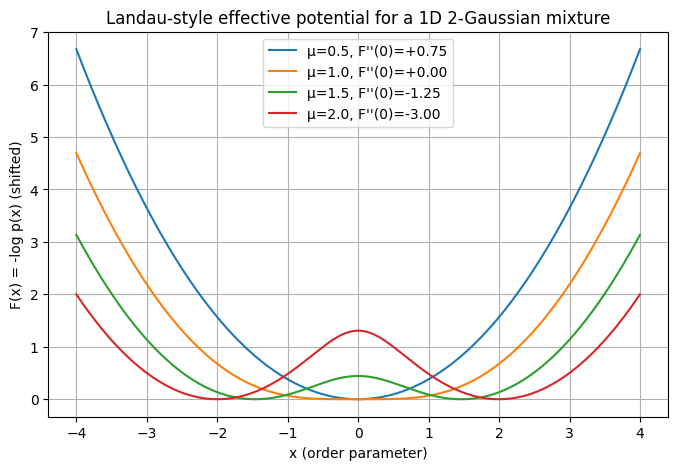

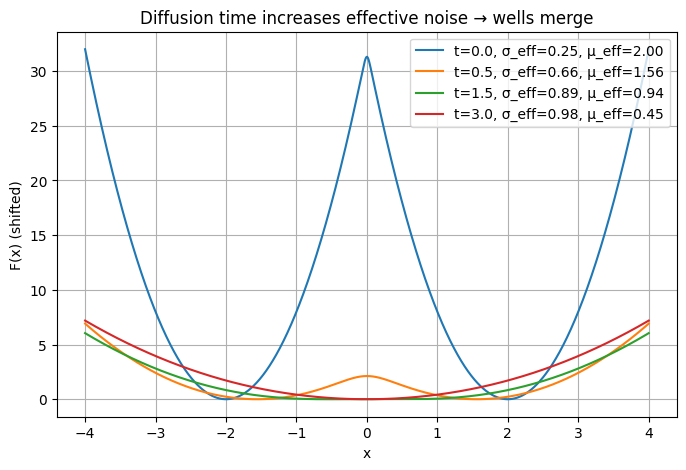

In [21]:
from scipy.stats import norm

def log_mixture_1d(x, mu, sig):
    # p(x)=0.5 N(x;mu,sig^2)+0.5 N(x;-mu,sig^2)
    p = 0.5*norm.pdf(x, loc=mu, scale=sig) + 0.5*norm.pdf(x, loc=-mu, scale=sig)
    return np.log(p + 1e-300)

def curvature_F_at_0(mu, sig):
    # F''(0) = 1/sig^2 - mu^2/sig^4
    return 1/(sig**2) - (mu**2)/(sig**4)

xs1 = np.linspace(-4,4,2000)
sig = 1.0
mus = [0.5, 1.0, 1.5, 2.0]

plt.figure(figsize=(8,5))
for mu in mus:
    F = -log_mixture_1d(xs1, mu=mu, sig=sig)
    F = F - F.min()
    plt.plot(xs1, F, label=f"μ={mu}, F''(0)={curvature_F_at_0(mu,sig):+.2f}")
plt.title("Landau-style effective potential for a 1D 2-Gaussian mixture")
plt.xlabel("x (order parameter)")
plt.ylabel("F(x) = -log p(x) (shifted)")
plt.legend()
plt.show()

# Now connect to diffusion time: treat sigma_eff(t)^2 = alpha^2 sigma0^2 + sigma(t)^2 in 1D
# We'll pick mu fixed and see wells merge as t increases.
mu = 2.0
sigma0_1d = 0.25  # "intrinsic" mode width
ts = [0.0, 0.5, 1.5, 3.0]
plt.figure(figsize=(8,5))
for t in ts:
    a, sig_t = alpha_sigma(t, beta=1.0)
    sigma_eff = np.sqrt((a**2)*sigma0_1d**2 + sig_t**2)
    F = -log_mixture_1d(xs1, mu=mu*a, sig=sigma_eff)  # means also contract by alpha in OU marginal
    F = F - F.min()
    plt.plot(xs1, F, label=f"t={t}, σ_eff={sigma_eff:.2f}, μ_eff={mu*a:.2f}")
plt.title("Diffusion time increases effective noise → wells merge")
plt.xlabel("x")
plt.ylabel("F(x) (shifted)")
plt.legend()
plt.show()


## 11.3 Replica method (minimal, concrete): Random Energy Model (REM)

The **replica trick** is a technique to compute quenched averages like $\mathbb{E}[\log Z]$ using:

$$
\mathbb{E}[\log Z]
=
\lim_{n\to 0}
\frac{\mathbb{E}[Z^n]-1}{n}
\quad\text{or}\quad
\mathbb{E}[\log Z]
=
\lim_{n\to 0}
\frac{1}{n}\log \mathbb{E}[Z^n],
$$

depending on assumptions and saddle-point steps.

A classic minimal setting is the **Random Energy Model**:

- There are $K=2^N$ states $i$.
- Energies $E_i\sim \mathcal{N}(0,N)$ i.i.d.
- Partition function:

$$
Z(\beta)=\sum_{i=1}^{2^N} e^{-\beta E_i}.
$$

Define free energy per spin:

$$
f(\beta)= -\frac{1}{\beta N}\log Z(\beta).
$$

---

### Known REM result (large $N$)

There is a critical inverse temperature:

$$
\beta_c=\sqrt{2\log 2}.
$$

For large $N$:

$$
f(\beta)=
\begin{cases}
-\dfrac{\log 2}{\beta}-\dfrac{\beta}{2},
& \beta\le \beta_c \\[6pt]
-\sqrt{2\log 2},
& \beta\ge \beta_c.
\end{cases}
$$

---

### Interpretation

- Small $\beta$: many states contribute  
  (high entropy, “uncommitted” phase).
- Large $\beta$: dominated by the minimum-energy state  
  (low entropy, “committed/speciated” phase).

---

### Connection to diffusion / guidance intuition

Guidance weights $w$ behave like an **inverse temperature** in a log-sum-exp competition between modes: larger $w$ concentrates mass on fewer modes.

We will:
- simulate REM for moderate $N$,
- estimate $\mathbb{E}[f(\beta)]$ over disorder,
- compare to the theoretical curve and observe the transition.

---

### Assumptions / limitations (explicit)

- The closed-form curve is an *asymptotic* $N\to\infty$ result.
- Replica derivations typically assume replica symmetry and saddle-point interchange of limits.
- Finite $N$ smooths the transition.


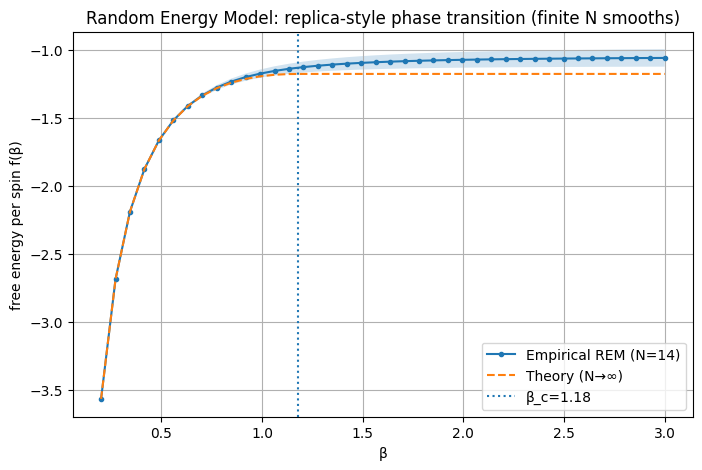

In [22]:
from scipy.special import logsumexp

def rem_free_energy(beta_vals, N=14, n_disorder=50, seed=0):
    rng = np.random.default_rng(seed)
    K = 2**N
    f = np.zeros((n_disorder, len(beta_vals)))
    for m in range(n_disorder):
        E = rng.normal(loc=0.0, scale=np.sqrt(N), size=K)  # var N
        for j, beta_ in enumerate(beta_vals):
            logZ = logsumexp(-beta_ * E)
            f[m,j] = -(1/(beta_ * N)) * logZ
    return f.mean(axis=0), f.std(axis=0)

def rem_theory(beta_vals):
    beta_c = np.sqrt(2*np.log(2))
    f_th = np.zeros_like(beta_vals, dtype=float)
    for i, b in enumerate(beta_vals):
        if b <= beta_c:
            f_th[i] = -(np.log(2)/b) - b/2
        else:
            f_th[i] = -np.sqrt(2*np.log(2))
    return f_th, beta_c

beta_vals = np.linspace(0.2, 3.0, 40)
f_emp, f_std = rem_free_energy(beta_vals, N=14, n_disorder=80, seed=1)
f_th, beta_c = rem_theory(beta_vals)

plt.figure(figsize=(8,5))
plt.plot(beta_vals, f_emp, marker="o", markersize=3, label="Empirical REM (N=14)")
plt.fill_between(beta_vals, f_emp - f_std, f_emp + f_std, alpha=0.2)
plt.plot(beta_vals, f_th, linestyle="--", label="Theory (N→∞)")
plt.axvline(beta_c, linestyle=":", label=f"β_c={beta_c:.2f}")
plt.title("Random Energy Model: replica-style phase transition (finite N smooths)")
plt.xlabel("β")
plt.ylabel("free energy per spin f(β)")
plt.legend()
plt.show()


# 12) What This Animation Implements

In this section we built and animated an **exactly solvable diffusion model**: a 2D Gaussian mixture evolving under Ornstein–Uhlenbeck (OU) forward diffusion, visualized in reverse time.

---

## 12.1 Initial Distribution

We start from a Gaussian mixture with $K=2$ components:

$$
p_0(x)=\sum_{k=1}^2 w_k\,\mathcal{N}(x;\mu_{0,k},\Sigma_{0,k}),
$$

where:
- $w_k$ are mixture weights,
- $\mu_{0,k}\in\mathbb{R}^2$ are means,
- $\Sigma_{0,k}$ are full (correlated) covariances.

Geometrically: two tilted ellipses in the plane.

---

## 12.2 Forward OU Diffusion

Each point evolves as

$$
X_t = e^{-t}X_0 + \sqrt{1-e^{-2t}}\,Z,
\quad Z\sim\mathcal{N}(0,I).
$$

For each Gaussian component:

- Mean:
  $$
  \mu_k(t)=e^{-t}\mu_{0,k}
  $$

- Covariance:
  $$
  \Sigma_k(t)=e^{-2t}\Sigma_{0,k} + (1-e^{-2t})I.
  $$

So the mixture remains Gaussian:

$$
p_t(x)=\sum_{k=1}^2 w_k\,\mathcal{N}(x;\mu_k(t),\Sigma_k(t)).
$$

As $t\to\infty$:
- $\mu_k(t)\to 0$
- $\Sigma_k(t)\to I$

and the mixture collapses to $\mathcal{N}(0,I)$ (pure noise).

---

## 12.3 What the Animation Shows

We visualize **reverse time**

$$
\tau = T - t,
$$

so we move from noise back to structured data.

Each frame displays:

1. Full density contours $p_t(x)$  
2. Component ellipses defined by
   $$
   (x-\mu_k(t))^\top \Sigma_k(t)^{-1}(x-\mu_k(t)) = r^2
   $$
3. Analytic 1D marginals $p_t(x_1)$ and $p_t(x_2)$

---

## 12.4 Conceptual Meaning

This is a closed-form demonstration of the diffusion principle:

- Forward process: exponential decay of means ($e^{-t}$) and anisotropy ($e^{-2t}$)
- Noise injection: isotropic variance $(1-e^{-2t})I$
- Reverse view: gradual reconstruction of multimodal structure from noise

(Anisotropy is the structural property of non-uniformity in different directions, as opposed to isotropy. An anisotropic object or pattern has properties that differ according to direction of measurement.)

Because everything is Gaussian, we know $p_t(x)$ exactly.

In real diffusion models, $p_t(x)$ is unknown — we instead learn the **score**

$$
s(x,t)=\nabla_x\log p_t(x),
$$

which defines the reverse-time generative dynamics.

This example serves as a clean analytical laboratory for understanding score-based generative modeling.


In [23]:
# If Plotly isn't installed, uncomment the next line:
# !pip -q install plotly

import numpy as np
from numpy.linalg import inv, det, cholesky
from scipy.stats import chi2, norm

import plotly.graph_objects as go
import plotly.io as pio

# Good default for Jupyter
# You can switch to "browser" if your notebook renderer has issues.
pio.renderers.default = "notebook_connected"


In [24]:
import plotly.io as pio
pio.renderers.default = "browser"


# ----------------------------
# Mixture definition at t = 0
# ----------------------------
K = 2
w = np.array([0.55, 0.45])  # weights sum to 1

# Means chosen to resemble "two tilted ellipses" separated in the plane
mu0 = np.array([
    [1.2, 0.8],   # component 1
    [2.2, 2.8],   # component 2
])

# Positive-definite covariances (with correlations) -> tilted ellipses
Sigma0 = np.array([
    [[0.25,  0.18],
     [0.18,  0.60]],
    
    [[0.35, -0.15],
     [-0.15, 0.25]],
])

I2 = np.eye(2)

def ou_component_params(mu0_k, Sigma0_k, t):
    """
    OU/VP forward diffusion:
      X_t = e^{-t} X_0 + sqrt(1 - e^{-2t}) Z,   Z~N(0,I)
    For a Gaussian component N(mu0, Sigma0), this yields:
      mu(t) = e^{-t} mu0
      Sigma(t) = e^{-2t} Sigma0 + (1 - e^{-2t}) I
    """
    a = np.exp(-t)
    b = np.exp(-2*t)
    mu_t = a * mu0_k
    Sigma_t = b * Sigma0_k + (1 - b) * I2
    return mu_t, Sigma_t

def ou_mixture_params(mu0, Sigma0, t):
    mu_t = np.zeros_like(mu0)
    Sigma_t = np.zeros_like(Sigma0)
    for k in range(K):
        mu_t[k], Sigma_t[k] = ou_component_params(mu0[k], Sigma0[k], t)
    return mu_t, Sigma_t

def mixture_pdf_points(X, t):
    """
    Vectorized mixture density at points X (N,2).
    """
    mu_t, Sigma_t = ou_mixture_params(mu0, Sigma0, t)
    p = np.zeros(X.shape[0], dtype=float)

    for k in range(K):
        S = Sigma_t[k]
        iS = inv(S)
        d = X - mu_t[k]
        quad = np.sum((d @ iS) * d, axis=1)  # (x-mu)^T S^{-1} (x-mu)
        norm_const = 1.0 / (2*np.pi*np.sqrt(det(S)))
        p += w[k] * norm_const * np.exp(-0.5 * quad)
    return p

def mixture_pdf_grid(xgrid, ygrid, t):
    """
    Density on a mesh grid, returned as (len(ygrid), len(xgrid)) for Plotly.
    """
    Xg, Yg = np.meshgrid(xgrid, ygrid)
    pts = np.stack([Xg.ravel(), Yg.ravel()], axis=1)
    Z = mixture_pdf_points(pts, t)
    return Z.reshape(len(ygrid), len(xgrid))

def mixture_marginals_1d(xgrid, ygrid, t):
    """
    Analytic 1D marginals for a Gaussian mixture:
      p_t(x1) = sum_k w_k N(x1; mu_k1(t), Sigma_k11(t))
      p_t(x2) = sum_k w_k N(x2; mu_k2(t), Sigma_k22(t))
    """
    mu_t, Sigma_t = ou_mixture_params(mu0, Sigma0, t)

    px = np.zeros_like(xgrid, dtype=float)
    py = np.zeros_like(ygrid, dtype=float)

    for k in range(K):
        px += w[k] * norm.pdf(xgrid, loc=mu_t[k, 0], scale=np.sqrt(Sigma_t[k, 0, 0]))
        py += w[k] * norm.pdf(ygrid, loc=mu_t[k, 1], scale=np.sqrt(Sigma_t[k, 1, 1]))
    return px, py

def ellipse_points(mu, Sigma, mass=0.80, n=240):
    """
    Ellipse enclosing given probability mass for a 2D Gaussian:
    {x: (x-mu)^T Sigma^{-1} (x-mu) = r^2 }, where r^2 = chi2.ppf(mass, df=2)
    """
    r = np.sqrt(chi2.ppf(mass, df=2))
    L = cholesky(Sigma)  # Sigma = L L^T
    ang = np.linspace(0, 2*np.pi, n)
    circle = np.stack([np.cos(ang), np.sin(ang)], axis=0) * r
    pts = (L @ circle).T + mu
    return pts[:, 0], pts[:, 1]


In [26]:
# ----------------------------
# Animation settings
# ----------------------------
T_final = 2.4          # diffusion time T (large => closer to N(0,I))
n_frames = 45          # number of animation frames
ellipse_mass = 0.80    # probability mass for covariance ellipse

# Time grid: "reverse-time generation" view = go from T down to 0
times = np.linspace(T_final, 0.0, n_frames)

# ----------------------------
# Plot range (auto-ish)
# ----------------------------
# A conservative range based on means + several std devs
mu_t0, Sigma_t0 = ou_mixture_params(mu0, Sigma0, t=0.0)
max_mu = np.max(np.abs(mu_t0))
max_var = np.max(Sigma_t0) + 1.0  # guard
R = float(max_mu + 5*np.sqrt(max_var))

xmin, xmax = -R, R
ymin, ymax = -R, R

# Padding area for drawing marginals along axes (like your sketch)
pad = 0.25 * (xmax - xmin)   # size of reserved strip
xmin2, ymin2 = xmin - pad, ymin - pad

# Grids
nx = 140
ny = 140
xgrid = np.linspace(xmin, xmax, nx)
ygrid = np.linspace(ymin, ymax, ny)

# For marginal curves (same xgrid/ygrid is convenient)
# We'll scale curves into the padding strip so they look like "bumps"
def embed_x_marginal(px):
    # Draw along bottom strip: y = ymin2 + scale * normalized_density
    scale = 0.92 * pad
    pxn = px / (px.max() + 1e-12)
    y_curve = ymin2 + scale * pxn
    return y_curve

def embed_y_marginal(py):
    # Draw along left strip: x = xmin2 + scale * normalized_density
    scale = 0.92 * pad
    pyn = py / (py.max() + 1e-12)
    x_curve = xmin2 + scale * pyn
    return x_curve

# Colors for the two ellipses (component 0 is red-ish, component 1 is black-ish)
ellipse_colors = ["#d62728", "#111111"]


# ----------------------------
# Build initial traces (at t = times[0] = T)
# ----------------------------
t_init = float(times[0])
Z_init = mixture_pdf_grid(xgrid, ygrid, t_init)
px_init, py_init = mixture_marginals_1d(xgrid, ygrid, t_init)

mu_t, Sigma_t = ou_mixture_params(mu0, Sigma0, t_init)

# Density contour
density_trace = go.Contour(
    x=xgrid, y=ygrid, z=Z_init,
    contours=dict(showlines=False),
    colorscale="Viridis",
    showscale=False,
    hoverinfo="skip",
    opacity=0.95,
    name="p_t(x)"
)

# Component ellipses
ellipse_traces = []
for k in range(K):
    ex, ey = ellipse_points(mu_t[k], Sigma_t[k], mass=ellipse_mass)
    ellipse_traces.append(
        go.Scatter(
            x=ex, y=ey, mode="lines",
            line=dict(width=3, color=ellipse_colors[k]),
            hoverinfo="skip",
            name=f"ellipse comp {k}"
        )
    )

# Marginal curves along axes (embedded into the padding strips)
x_marg_trace = go.Scatter(
    x=xgrid,
    y=embed_x_marginal(px_init),
    mode="lines",
    line=dict(width=3, color="#000000"),
    hoverinfo="skip",
    name="p_t(x1) (embedded)"
)

y_marg_trace = go.Scatter(
    x=embed_y_marginal(py_init),
    y=ygrid,
    mode="lines",
    line=dict(width=3, color="#000000"),
    hoverinfo="skip",
    name="p_t(x2) (embedded)"
)

# A faint rectangle to indicate the main density square region (optional but helps visually)
box_trace = go.Scatter(
    x=[xmin, xmax, xmax, xmin, xmin],
    y=[ymin, ymin, ymax, ymax, ymin],
    mode="lines",
    line=dict(width=1, color="rgba(0,0,0,0.35)"),
    hoverinfo="skip",
    name="support box"
)

data_traces = [density_trace] + ellipse_traces + [x_marg_trace, y_marg_trace, box_trace]

# ----------------------------
# Build frames
# ----------------------------
frames = []
for i, t in enumerate(times):
    t = float(t)
    Z = mixture_pdf_grid(xgrid, ygrid, t)
    px, py = mixture_marginals_1d(xgrid, ygrid, t)
    mu_t, Sigma_t = ou_mixture_params(mu0, Sigma0, t)

    frame_data = []

    # 0) density contour update (only z changes)
    frame_data.append(go.Contour(z=Z))

    # 1..K) ellipse updates
    for k in range(K):
        ex, ey = ellipse_points(mu_t[k], Sigma_t[k], mass=ellipse_mass)
        frame_data.append(go.Scatter(x=ex, y=ey))

    # marginals
    frame_data.append(go.Scatter(x=xgrid, y=embed_x_marginal(px)))
    frame_data.append(go.Scatter(x=embed_y_marginal(py), y=ygrid))

    # box stays the same -> keep as None by not updating (but Plotly wants consistent list length)
    frame_data.append(go.Scatter(x=[xmin, xmax, xmax, xmin, xmin],
                                 y=[ymin, ymin, ymax, ymax, ymin]))

    frames.append(go.Frame(data=frame_data, name=f"{i}", layout=go.Layout(
        title=f"Reverse-time view:  p(T) → p(τ),   τ = {t:.3f}"
    )))

# ----------------------------
# Slider + play/pause controls
# ----------------------------
slider_steps = []
for i, t in enumerate(times):
    slider_steps.append({
        "method": "animate",
        "args": [[f"{i}"], {"mode": "immediate", "frame": {"duration": 70, "redraw": True},
                            "transition": {"duration": 0}}],
        "label": f"{float(t):.2f}"
    })

sliders = [{
    "active": 0,
    "pad": {"t": 45, "b": 10},
    "currentvalue": {"prefix": "τ = "},
    "steps": slider_steps
}]

updatemenus = [{
    "type": "buttons",
    "direction": "left",
    "x": 0.02,
    "y": 1.08,
    "buttons": [
        {
            "label": "▶ Play",
            "method": "animate",
            "args": [None, {"frame": {"duration": 70, "redraw": True},
                            "fromcurrent": True,
                            "transition": {"duration": 0}}]
        },
        {
            "label": "⏸ Pause",
            "method": "animate",
            "args": [[None], {"frame": {"duration": 0, "redraw": False},
                              "mode": "immediate",
                              "transition": {"duration": 0}}]
        }
    ]
}]

# ----------------------------
# Layout
# ----------------------------
fig = go.Figure(data=data_traces, frames=frames)

fig.update_layout(
    title=f"Reverse-time view:  p(T) → p(τ),   τ = {t_init:.3f}",
    width=820,
    height=820,
    margin=dict(l=40, r=30, t=95, b=40),
    xaxis=dict(range=[xmin2, xmax], zeroline=False, title="x₁"),
    yaxis=dict(range=[ymin2, ymax], zeroline=False, title="x₂"),
    yaxis_scaleanchor="x",
    sliders=sliders,
    updatemenus=updatemenus,
    legend=dict(orientation="h", yanchor="bottom", y=1.01, xanchor="right", x=1.0)
)

fig.show()
